# Lab Assignment 7: Deep Learning Grid Search with Scikit-Learn & Keras (AI in Healthcare)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/achalzz/ai-healthcare-cset343/blob/main/Lab_Assignment_7_AI_in_Healthcare.ipynb)

**Course:** B.Tech Specialization Elective (4th Year, Sem VII)  
**Course Code:** CSET343 - AI in Healthcare  
**Assignment:** Lab Assignment 7 - Grid-Search Capability of Scikit-Learn on Deep Learning Models (Pima Indians Diabetes Dataset)  

---

### Objectives & Agenda:
1. **Task 1: Data Acquisition and Loading** — Download and load the Pima Indians Diabetes dataset, inspect features, analyze summary statistics, audit missing values (biologically impossible zeros), and visualize distributions, correlations, and class balance.
2. **Task 2: Data Preprocessing** — Clinically sound missing value imputation (KNN Imputer), stratified train-test splitting (80/20), feature standardization (`StandardScaler`), and 2D latent space projections (PCA & t-SNE).
3. **Task 3: Deep Learning Grid Search** — Design a Keras deep learning model wrapped in Scikit-Learn (`scikeras.wrappers.KerasClassifier`) and systematically tune hyperparameters using Scikit-Learn `GridSearchCV`:
   - Tune batch size and training epochs
   - Tune learning rate and optimization algorithm
   - Tune network weight initialization
   - Tune activation functions
   - Tune dropout regularization
   - Tune the number of neurons in the hidden layer
   - Train final optimized model, evaluate on test cohort, compare against baseline, and simulate a Clinical Decision Support System (CDSS).


In [1]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein deep learning aur hyperparameter tuning ke required libraries setup kiye gaye hain.
# Step 1: NumPy, Pandas, Matplotlib, Seaborn aur Scipy import kiye.
# Step 2: TensorFlow aur Keras deep learning modules import kiye aur C++ backend logs suppress kiye.
# Step 3: Scikit-learn se GridSearchCV, StratifiedKFold, StandardScaler, KNNImputer aur evaluation metrics load kiye.
# Step 4: SciKeras se KerasClassifier wrapper import kiya taaki Keras model Scikit-learn ke GridSearch ke saath directly chal sake.
# Step 5: Deterministic results ke liye random seed 42 set kiya.
# ====================================================================
import sys
import os
import io
import time
import math
import random
import warnings
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Suppress TensorFlow C++ backend logs & tracing notifications
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

# Deep Learning Frameworks: TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from keras import layers
tf.get_logger().setLevel('ERROR')

# Scikit-Learn & SciKeras Wrappers
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score, brier_score_loss,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef
)
from sklearn.calibration import calibration_curve

# Global Styling Configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 1.0

# Set deterministic random seed for strict reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"[INFO] Python Version:     {sys.version.split()[0]}")
print(f"[INFO] NumPy Version:      {np.__version__}")
print(f"[INFO] Pandas Version:     {pd.__version__}")
print(f"[INFO] TensorFlow Version: {tf.__version__}")
print(f"[INFO] Keras Version:      {keras.__version__}")
print(f"[INFO] Seed Configured:    {SEED} (Fully Deterministic)")


[INFO] Python Version:     3.11.9
[INFO] NumPy Version:      2.3.5
[INFO] Pandas Version:     3.0.2
[INFO] TensorFlow Version: 2.21.0
[INFO] Keras Version:      3.15.1
[INFO] Seed Configured:    42 (Fully Deterministic)


# Task 1: Data Acquisition and Exploration


In [2]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Pima Indians Diabetes dataset acquire aur load kiya gaya.
# Step 1: Multi-tier loading mechanism lagaya: pehle local cache check kiya, agar na mile toh GitHub/online URL se load kiya.
# Step 2: Dataset ko local file 'pima-indians-diabetes.csv' mein cache kiya taaki future offline runs smoothly chal sakein.
# Step 3: Dataset ke total rows (768), columns (8 features + 1 outcome) aur first 5 records display kiye.
# ====================================================================
feature_columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]
target_column = 'Outcome'
all_columns = feature_columns + [target_column]

# Multi-tier loading pipeline: Local cache -> Primary GitHub repo -> Plotly backup
df_raw = None
local_path = "pima-indians-diabetes.csv"

if os.path.exists(local_path):
    try:
        df_raw = pd.read_csv(local_path)
        if list(df_raw.columns) != all_columns and df_raw.shape[1] == 9:
            df_raw.columns = all_columns
        print(f"[SUCCESS] Loaded dataset from local cache: '{local_path}'")
    except Exception as e:
        print(f"[WARNING] Failed reading local file: {e}")

if df_raw is None:
    urls = [
        "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv",
        "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
    ]
    for url in urls:
        try:
            print(f"[INFO] Attempting download from: {url}")
            temp_df = pd.read_csv(url, header=None if "jbrownlee" in url else 0)
            if temp_df.shape[1] == 9:
                temp_df.columns = all_columns
                df_raw = temp_df
                df_raw.to_csv(local_path, index=False)
                print(f"[SUCCESS] Downloaded and cached dataset from {url}")
                break
        except Exception as e:
            print(f"[WARNING] Download failed from {url}: {e}")

print("\n" + "=" * 60)
print("PIMA INDIANS DIABETES DATASET - ARCHITECTURAL OVERVIEW")
print("=" * 60)
print(f"Total Patient Records (Rows):       {df_raw.shape[0]}")
print(f"Total Clinical Features (Columns):  {len(feature_columns)}")
print(f"Target Diagnostic Variable:         '{target_column}' (0: Non-Diabetic, 1: Diabetic)")
print(f"Memory Utilization:                 {df_raw.memory_usage().sum() / 1024:.2f} KB")
print("\nFirst 5 Clinical Patient Records:")
display(df_raw.head())


[SUCCESS] Loaded dataset from local cache: 'pima-indians-diabetes.csv'

PIMA INDIANS DIABETES DATASET - ARCHITECTURAL OVERVIEW
Total Patient Records (Rows):       768
Total Clinical Features (Columns):  8
Target Diagnostic Variable:         'Outcome' (0: Non-Diabetic, 1: Diabetic)
Memory Utilization:                 54.13 KB

First 5 Clinical Patient Records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72             35        0  33.6                     0.627   50        1
1            1       85             66             29        0  26.6                     0.351   31        0
2            8      183             64              0        0  23.3                     0.672   32        1
3            1       89             66             23       94  28.1                     0.167   21        0
4            0      137             40             35      168  43.1                     2.28

In [3]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein dataset ke andar biologically impossible zero values ka audit kiya gaya.
# Step 1: Glucose, BloodPressure, SkinThickness, Insulin aur BMI mein 0 value human life ke liye physiologically impossible hai, jo missing entries represent karti hain.
# Step 2: Har feature mein zero values ka count aur percentage calculate karke audit table banayi.
# Step 3: Sabhi continuous features ka descriptive statistical profile (mean, std, median, skewness, kurtosis) compute kiya.
# ====================================================================
biomarkers_with_missing_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_audit = []
for col in df_raw.columns:
    zero_cnt = (df_raw[col] == 0).sum()
    zero_pct = (zero_cnt / len(df_raw)) * 100
    is_biologically_invalid = col in biomarkers_with_missing_zeros
    zero_audit.append({
        'Biomarker': col,
        'Zero Count': zero_cnt,
        'Zero Percentage (%)': round(zero_pct, 2),
        'Physiologically Feasible as Zero': 'No (Missing Entry)' if is_biologically_invalid else 'Yes (Valid Gravidity/Target)'
    })

df_zero_audit = pd.DataFrame(zero_audit)
print("=== CLINICAL BIOMARKER ZERO-VALUE AUDIT ===")
display(df_zero_audit)

# Statistical Summary Profile across all 8 biomarkers
stats_summary = df_raw[feature_columns].describe().T
stats_summary['median'] = df_raw[feature_columns].median()
stats_summary['skewness'] = df_raw[feature_columns].skew()
stats_summary['kurtosis'] = df_raw[feature_columns].kurtosis()
stats_summary = stats_summary[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'skewness', 'kurtosis']]

print("\n=== CLINICAL DESCRIPTIVE STATISTICAL PROFILE ===")
display(stats_summary.round(3))


=== CLINICAL BIOMARKER ZERO-VALUE AUDIT ===
                  Biomarker  Zero Count  Zero Percentage (%) Physiologically Feasible as Zero
0               Pregnancies         111                14.45     Yes (Valid Gravidity/Target)
1                   Glucose           5                 0.65               No (Missing Entry)
2             BloodPressure          35                 4.56               No (Missing Entry)
3             SkinThickness         227                29.56               No (Missing Entry)
4                   Insulin         374                48.70               No (Missing Entry)
5                       BMI          11                 1.43               No (Missing Entry)
6  DiabetesPedigreeFunction           0                 0.00     Yes (Valid Gravidity/Target)
7                       Age           0                 0.00     Yes (Valid Gravidity/Target)
8                   Outcome         500                65.10     Yes (Valid Gravidity/Target)

=== CLINICAL DE

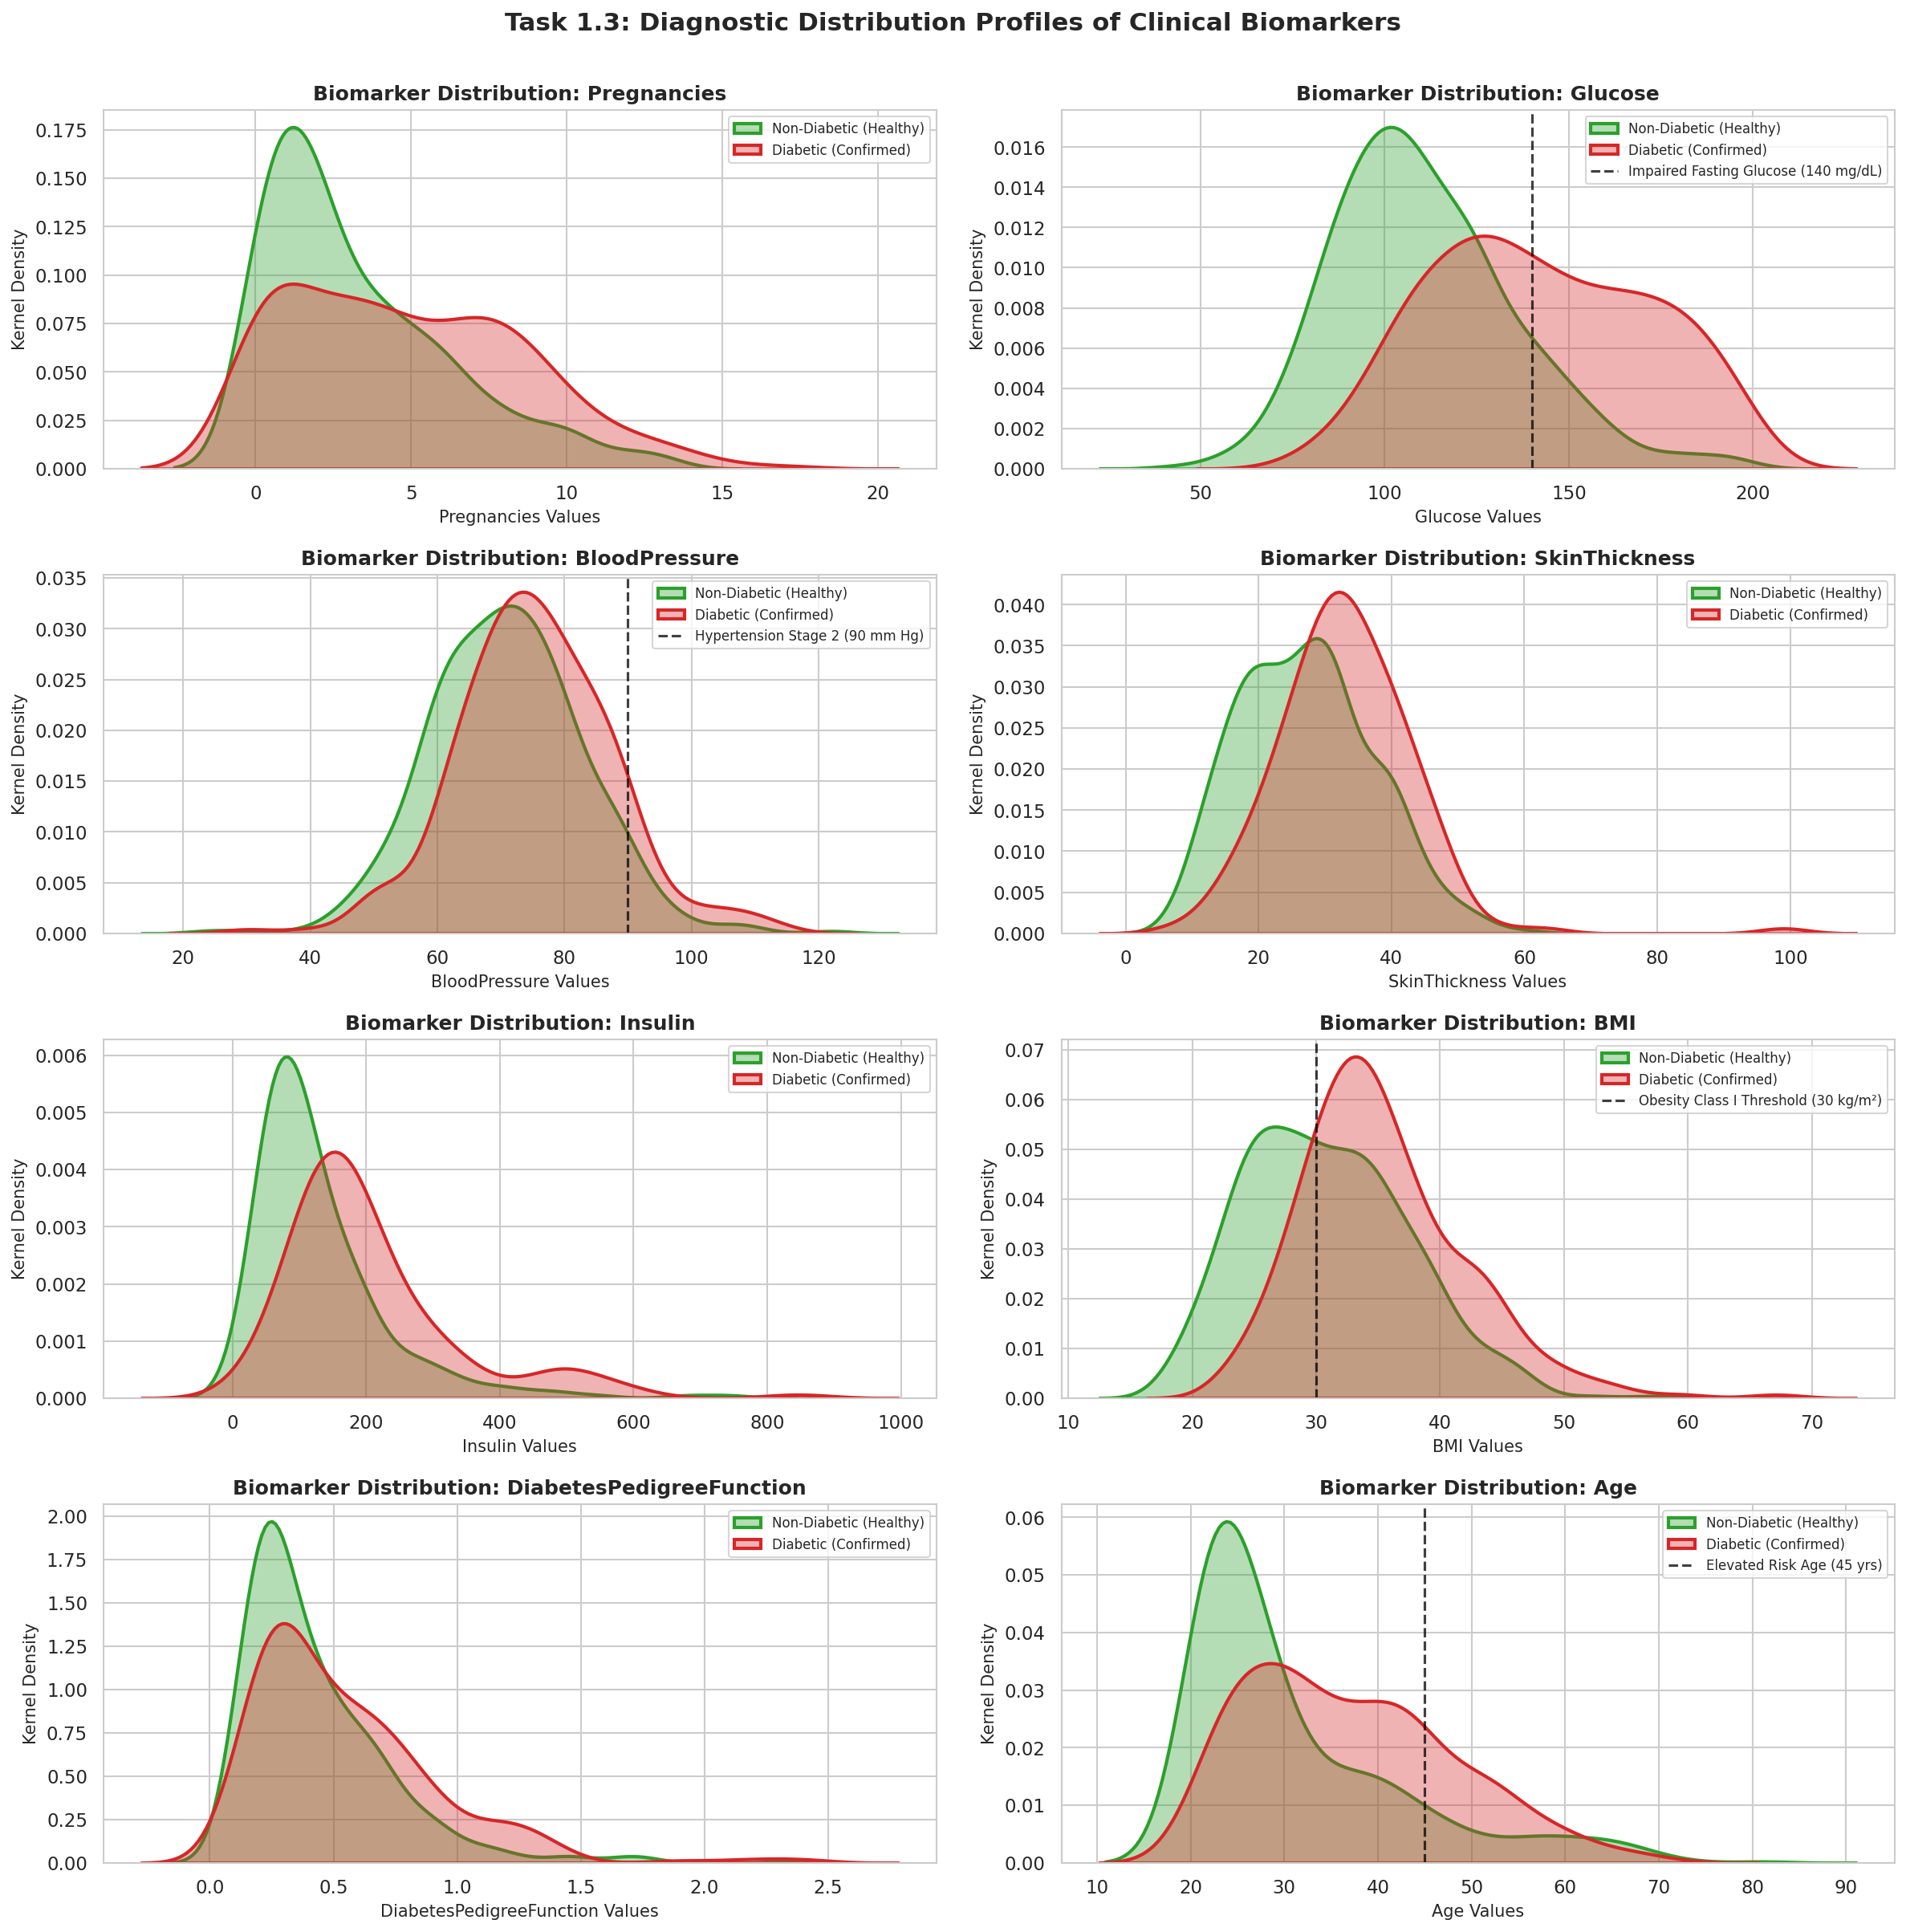

In [4]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein sabhi 8 clinical biomarkers ki distribution curves plot ki gayi hain.
# Step 1: Har biomarker ke liye Diabetic (Red) vs Non-Diabetic (Green) cohorts ko Kernel Density Estimation (KDE) se compare kiya.
# Step 2: Clinical diagnostic cutoffs (jaise Impaired Fasting Glucose 140 mg/dL, Obesity BMI 30 kg/m²) mark kiye.
# Step 3: Visualize kiya ki diabetic patients mein Glucose, Insulin aur BMI significantly right-skewed aur elevated hain.
# ====================================================================
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

clinical_reference_lines = {
    'Glucose': (140, 'Impaired Fasting Glucose (140 mg/dL)'),
    'BloodPressure': (90, 'Hypertension Stage 2 (90 mm Hg)'),
    'BMI': (30, 'Obesity Class I Threshold (30 kg/m²)'),
    'Age': (45, 'Elevated Risk Age (45 yrs)')
}

palette = {0: '#2ca02c', 1: '#d62728'}
labels = {0: 'Non-Diabetic (Healthy)', 1: 'Diabetic (Confirmed)'}

for idx, col in enumerate(feature_columns):
    ax = axes[idx]
    if col in biomarkers_with_missing_zeros:
        plot_data = df_raw[df_raw[col] > 0]
    else:
        plot_data = df_raw
        
    for outcome_val in [0, 1]:
        subset = plot_data[plot_data['Outcome'] == outcome_val][col]
        sns.kdeplot(
            subset,
            ax=ax,
            fill=True,
            alpha=0.35,
            color=palette[outcome_val],
            label=labels[outcome_val],
            linewidth=2
        )
    
    if col in clinical_reference_lines:
        ref_val, ref_label = clinical_reference_lines[col]
        ax.axvline(ref_val, color='black', linestyle='--', linewidth=1.5, alpha=0.75, label=ref_label)
        
    ax.set_title(f"Biomarker Distribution: {col}", fontsize=12, fontweight='bold')
    ax.set_xlabel(f"{col} Values", fontsize=10)
    ax.set_ylabel("Kernel Density", fontsize=10)
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle("Task 1.3: Diagnostic Distribution Profiles of Clinical Biomarkers", fontsize=15, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show()


=== CLINICAL IMPLICATIONS OF CLASS IMBALANCE ===
1. Natural Prevalence: The cohort presents a 34.9% diabetic prevalence vs 65.1% non-diabetic.
2. Asymmetry of Diagnostic Costs: In diabetes screening, a False Negative (failing to identify an asymptomatic diabetic patient)
   leads to delayed glycemic control, microvascular deterioration, and avoidable diabetic ketoacidosis or retinopathy.
3. Conversely, a False Positive causes temporary patient anxiety and triggers secondary confirmatory lab testing (fasting HbA1c/OGTT).
   Therefore, hyperparameter tuning should emphasize balanced sensitivity without catastrophic collapse in specificity.


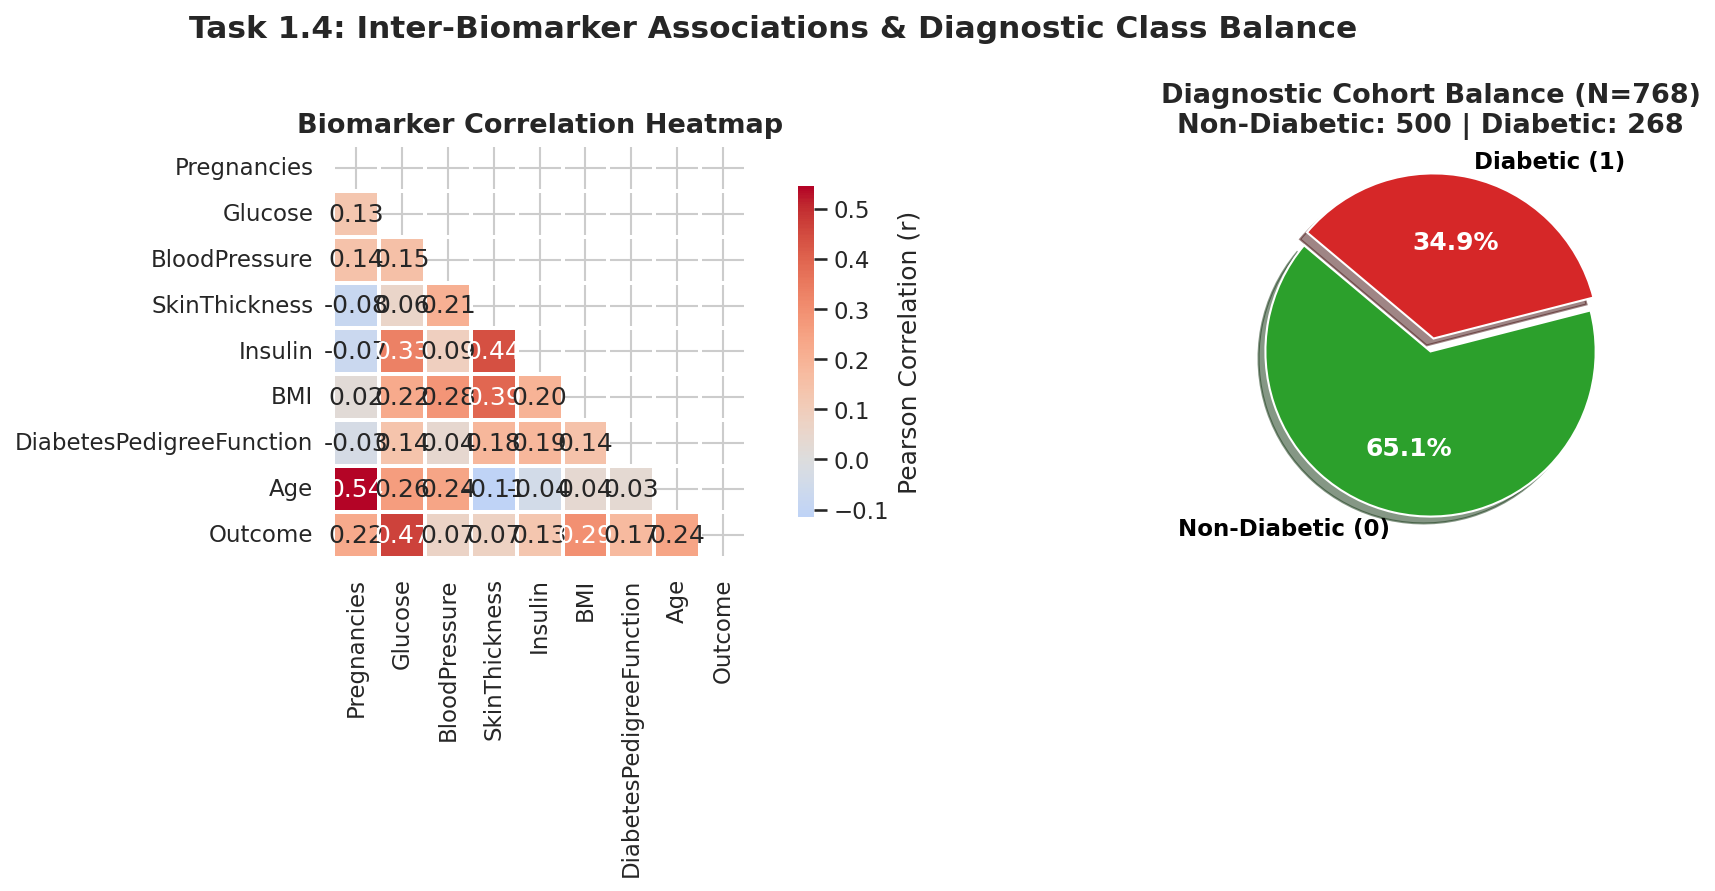

In [5]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein biomarker correlation structure aur diagnostic class balance analyze kiya gaya.
# Step 1: Pearson correlation matrix compute karke triangular heatmap plot kiya (Glucose vs Outcome ka highest correlation r ≈ 0.47 dikha).
# Step 2: Class balance pie chart plot kiya: 500 Non-diabetic (65.1%) vs 268 Diabetic (34.9%).
# Step 3: Healthcare screening perspective se False Negatives aur False Positives ke clinical trade-offs print kiye.
# ====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Pearson Correlation Heatmap
corr_matrix = df_raw.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1.0,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation (r)"},
    ax=axes[0]
)
axes[0].set_title("Biomarker Correlation Heatmap", fontsize=13, fontweight='bold')

# 2. Class Balance Analysis
outcome_counts = df_raw['Outcome'].value_counts()
outcome_labels = ['Non-Diabetic (0)', 'Diabetic (1)']
colors = ['#2ca02c', '#d62728']

wedges, texts, autotexts = axes[1].pie(
    outcome_counts,
    labels=outcome_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0, 0.08),
    shadow=True,
    textprops=dict(color="black", fontweight="bold", fontsize=11)
)
for at in autotexts:
    at.set_color("white")
    at.set_fontsize(12)

axes[1].set_title(
    f"Diagnostic Cohort Balance (N={len(df_raw)})\n"
    f"Non-Diabetic: {outcome_counts[0]} | Diabetic: {outcome_counts[1]}",
    fontsize=13,
    fontweight='bold'
)

plt.suptitle("Task 1.4: Inter-Biomarker Associations & Diagnostic Class Balance", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Clinical Imbalance Commentary
print("=== CLINICAL IMPLICATIONS OF CLASS IMBALANCE ===")
print(f"1. Natural Prevalence: The cohort presents a {outcome_counts[1]/len(df_raw)*100:.1f}% diabetic prevalence vs {outcome_counts[0]/len(df_raw)*100:.1f}% non-diabetic.")
print("2. Asymmetry of Diagnostic Costs: In diabetes screening, a False Negative (failing to identify an asymptomatic diabetic patient)")
print("   leads to delayed glycemic control, microvascular deterioration, and avoidable diabetic ketoacidosis or retinopathy.")
print("3. Conversely, a False Positive causes temporary patient anxiety and triggers secondary confirmatory lab testing (fasting HbA1c/OGTT).")
print("   Therefore, hyperparameter tuning should emphasize balanced sensitivity without catastrophic collapse in specificity.")


# Task 2: Data Preprocessing


=== DETECTED PHYSIOLOGICALLY IMPOSSIBLE MEASUREMENTS (NaNs) ===
 - Glucose        :   5 missing entries (0.65%)
 - BloodPressure  :  35 missing entries (4.56%)
 - SkinThickness  : 227 missing entries (29.56%)
 - Insulin        : 374 missing entries (48.70%)
 - BMI            :  11 missing entries (1.43%)

[SUCCESS] KNN Multivariate Imputation complete! Remaining NaNs: 0


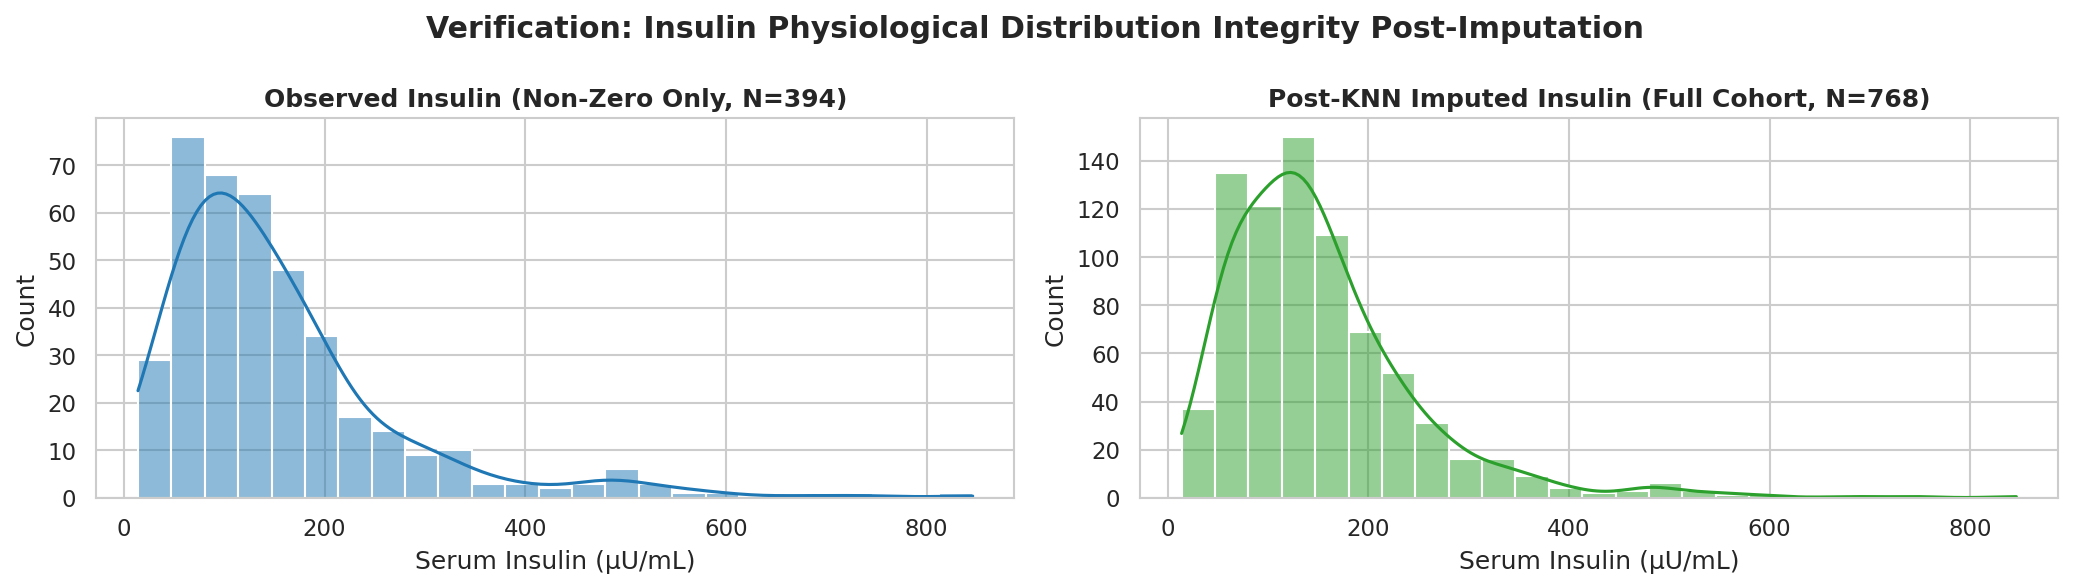

In [6]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein missing biomarker measurements ko clinically sound tarike se impute kiya gaya.
# Step 1: 5 biomarkers (Glucose, BP, SkinThickness, Insulin, BMI) mein biologically impossible 0s ko NaN se replace kiya (Pregnancies ke valid 0s ko preserve rakha).
# Step 2: KNNImputer (k=5) apply kiya, jo correlated features ki madad se missing values predict karta hai.
# Step 3: Imputation verify kiya ki koi bhi NaN bacha na ho aur Insulin distribution pre vs post plot karke distribution integrity check ki.
# ====================================================================
df_imputed = df_raw.copy()

# Replace biologically impossible 0s with NaN for the 5 affected features
df_imputed[biomarkers_with_missing_zeros] = df_imputed[biomarkers_with_missing_zeros].replace(0, np.nan)

nan_counts_before = df_imputed[biomarkers_with_missing_zeros].isna().sum()
print("=== DETECTED PHYSIOLOGICALLY IMPOSSIBLE MEASUREMENTS (NaNs) ===")
for col, cnt in nan_counts_before.items():
    print(f" - {col:15s}: {cnt:3d} missing entries ({cnt/len(df_raw)*100:.2f}%)")

# Apply K-Nearest Neighbors Imputer (k=5) using multivariate biomarker correlation
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
imputed_array = knn_imputer.fit_transform(df_imputed[feature_columns])
df_imputed[feature_columns] = pd.DataFrame(imputed_array, columns=feature_columns)

print(f"\n[SUCCESS] KNN Multivariate Imputation complete! Remaining NaNs: {df_imputed.isna().sum().sum()}")

# Verification: Compare pre- and post-imputation summary for heavily impacted Insulin feature
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_raw[df_raw['Insulin'] > 0]['Insulin'], kde=True, ax=ax[0], color='#1f77b4', bins=25)
ax[0].set_title("Observed Insulin (Non-Zero Only, N=394)", fontweight='bold')
ax[0].set_xlabel("Serum Insulin (μU/mL)")

sns.histplot(df_imputed['Insulin'], kde=True, ax=ax[1], color='#2ca02c', bins=25)
ax[1].set_title("Post-KNN Imputed Insulin (Full Cohort, N=768)", fontweight='bold')
ax[1].set_xlabel("Serum Insulin (μU/mL)")

plt.suptitle("Verification: Insulin Physiological Distribution Integrity Post-Imputation", fontweight='bold')
plt.tight_layout()
plt.show()


In [7]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein stratified train-test splitting aur feature standardization kiya gaya.
# Step 1: 80% Train aur 20% Holdout Test set mein split kiya, stratify=y use karke diabetic ratio (34.9%) dono sets mein exact preserve kiya.
# Step 2: StandardScaler ko strictly training data par fit kiya aur test data par transform kiya data leakage prevent karne ke liye.
# Step 3: Partition verification table banayi jo sample counts aur class percentages display karti hai.
# ====================================================================
X = df_imputed[feature_columns].values
y = df_imputed[target_column].values

# 80% Train, 20% Holdout Test with strict stratification
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Fit StandardScaler strictly on training partition
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

partition_summary = pd.DataFrame({
    'Partition': ['Full Cohort', 'Training Cohort (80%)', 'Holdout Test Cohort (20%)'],
    'Total Samples': [len(y), len(y_train), len(y_test)],
    'Non-Diabetic (0)': [(y == 0).sum(), (y_train == 0).sum(), (y_test == 0).sum()],
    'Diabetic (1)': [(y == 1).sum(), (y_train == 1).sum(), (y_test == 1).sum()],
    'Diabetic Prevalence (%)': [
        round((y == 1).mean() * 100, 2),
        round((y_train == 1).mean() * 100, 2),
        round((y_test == 1).mean() * 100, 2)
    ]
})

print("=== STRATIFIED PARTITION VERIFICATION TABLE ===")
display(partition_summary)


=== STRATIFIED PARTITION VERIFICATION TABLE ===
                   Partition  Total Samples  Non-Diabetic (0)  Diabetic (1)  Diabetic Prevalence (%)
0                Full Cohort            768               500           268                    34.90
1      Training Cohort (80%)            614               400           214                    34.85
2  Holdout Test Cohort (20%)            154               100            54                    35.06


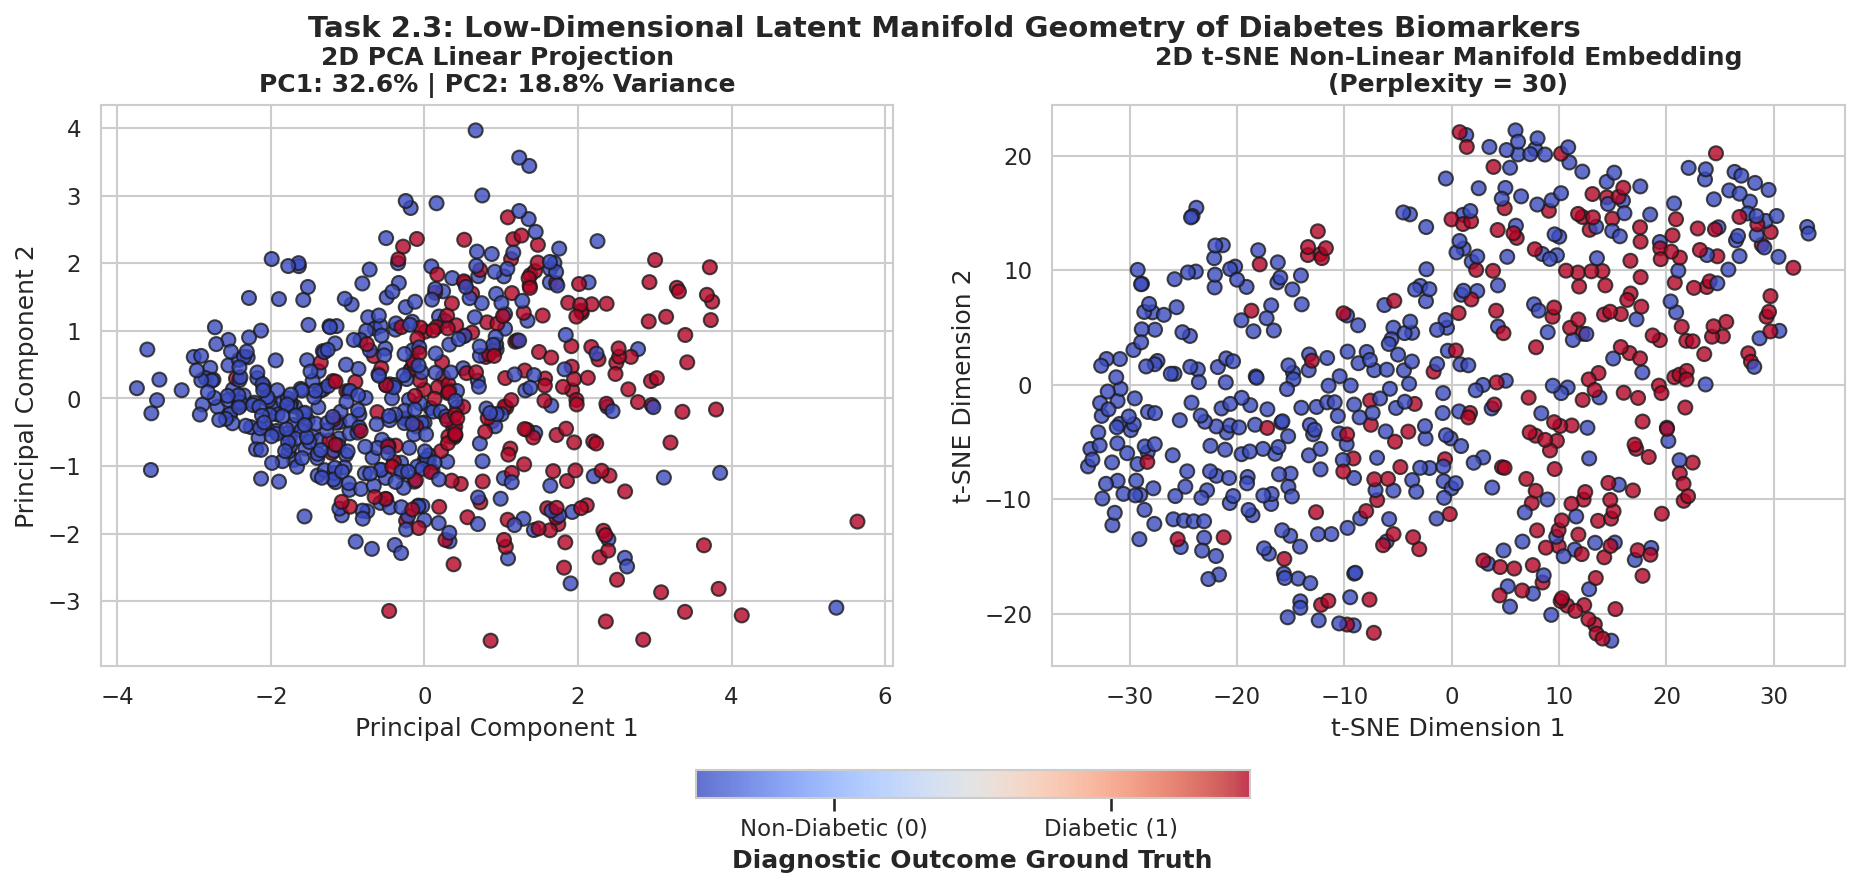

In [8]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein feature space ki class separability inspect karne ke liye low-dimensional embeddings plot ki gayi hain.
# Step 1: PCA (Linear dimension reduction) se 2 Principal Components extract kiye aur explained variance display kiya.
# Step 2: t-SNE (Non-linear manifold projection) se complex non-linear patient clusters plot kiye.
# Step 3: Color-coded scatter plots se visually verify kiya ki diabetic aur healthy patients feature space mein separate clusters form kar rahe hain.
# ====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Principal Component Analysis (Linear Dimension Reduction)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_train)
var_exp = pca.explained_variance_ratio_ * 100

scatter1 = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_train, cmap='coolwarm', alpha=0.8, edgecolor='k', s=45
)
axes[0].set_title(f"2D PCA Linear Projection\nPC1: {var_exp[0]:.1f}% | PC2: {var_exp[1]:.1f}% Variance", fontweight='bold')
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

# 2. t-SNE Manifold Projection (Non-Linear Dimension Reduction)
try:
    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
except TypeError:
    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
X_tsne = tsne.fit_transform(X_train)

scatter2 = axes[1].scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=y_train, cmap='coolwarm', alpha=0.8, edgecolor='k', s=45
)
axes[1].set_title("2D t-SNE Non-Linear Manifold Embedding\n(Perplexity = 30)", fontweight='bold')
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")

cbar = plt.colorbar(scatter2, ax=axes, orientation='horizontal', fraction=0.04, pad=0.15)
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
cbar.set_label("Diagnostic Outcome Ground Truth", fontweight='bold')

plt.suptitle("Task 2.3: Low-Dimensional Latent Manifold Geometry of Diabetes Biomarkers", fontsize=14, fontweight='bold')
plt.show()


# Task 3: Deep Learning Grid Search


In [9]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Scikit-Learn compatible parametric Keras deep neural network architecture define kiya gaya.
# Step 1: create_diabetes_model() function banaya jisme neurons, activation, initializer, dropout, optimizer aur learning rate configurable parameters hain.
# Step 2: Dense hidden layer, optional Dropout layer aur 1-neuron Sigmoid output layer add ki.
# Step 3: Binary Cross-Entropy loss aur Adam/RMSprop/SGD optimizer compile kiya.
# Step 4: Model architecture summary print karke trainable weights verify kiye.
# ====================================================================
def create_diabetes_model(
    hidden_neurons=16,
    activation='relu',
    init_mode='glorot_uniform',
    dropout_rate=0.0,
    learning_rate=0.005,
    optimizer_name='adam'
):
    model = keras.Sequential()
    model.add(layers.Input(shape=(8,)))
    
    # Hidden Layer with configurable units, activation, and weight initialization
    model.add(layers.Dense(
        hidden_neurons,
        activation=activation,
        kernel_initializer=init_mode,
        name='hidden_layer_1'
    ))
    
    # Optional Dropout Regularization
    if dropout_rate > 0.0:
        model.add(layers.Dropout(dropout_rate, name='dropout_1'))
        
    # Output Layer: Sigmoid activation for calibrated posterior probability P(Y=1|X)
    model.add(layers.Dense(
        1,
        activation='sigmoid',
        kernel_initializer=init_mode,
        name='output_layer'
    ))
    
    # Configurable Optimizer Selection
    opt_key = optimizer_name.lower()
    if opt_key == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif opt_key == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif opt_key == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
        
    model.compile(
        loss='binary_crossentropy',
        optimizer=opt,
        metrics=['accuracy']
    )
    return model

# Baseline model representation
sample_model = create_diabetes_model()
print("=== DEEP MULTILAYER PERCEPTRON ARCHITECTURE OVERVIEW ===")
sample_model.summary()
print(f"\n[INFO] Total Trainable Weights: {sample_model.count_params():,}")


=== DEEP MULTILAYER PERCEPTRON ARCHITECTURE OVERVIEW ===
Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 161 (644.00 B)
 Trainable params: 161 (644.00 B)
 Non-trainable params: 0 (0.00 B)

[INFO] Total Trainable Weights: 161


EXECUTING GRID SEARCH 1: BATCH SIZE & TRAINING EPOCHS
[SUCCESS] Grid Search 1 completed in 44.44 seconds.
Optimal Configuration: {'batch_size': 32, 'epochs': 50}
Best Mean CV Accuracy: 77.20%

   Batch Size  Epochs  Mean CV Accuracy  CV Std Dev 95% Confidence Interval
0          32      50          0.772007    0.018153        [0.7364, 0.8076]
1          16      25          0.770373    0.024737        [0.7219, 0.8189]
2          32      25          0.768747    0.026965        [0.7159, 0.8216]
3          16      50          0.765479    0.006650        [0.7524, 0.7785]


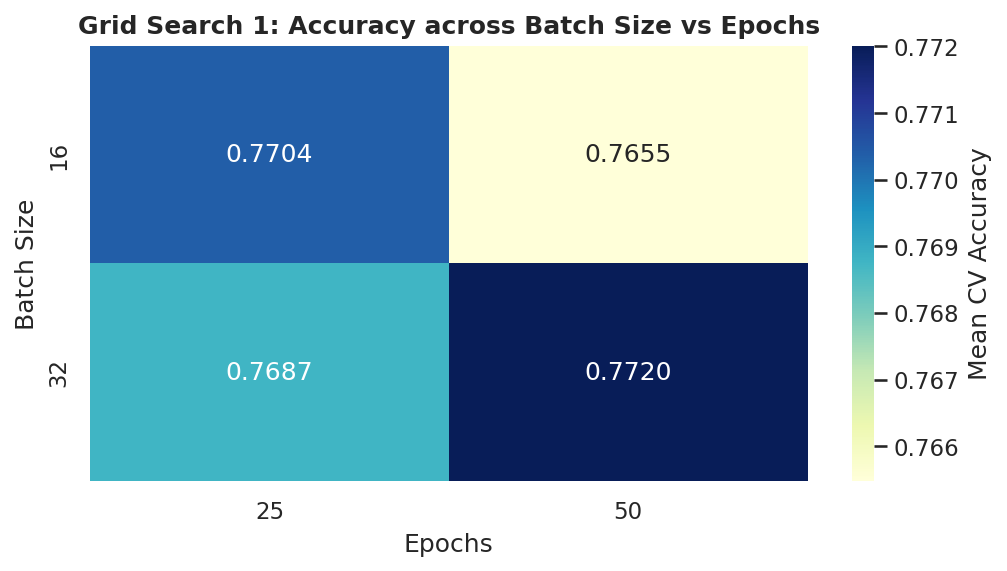

In [10]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Scikit-Learn GridSearchCV use karke Batch Size aur Training Epochs tune kiye gaye hain.
# Step 1: Parameter grid define kiya: batch_size in [16, 32] aur epochs in [25, 50].
# Step 2: 3-Fold Stratified Cross-Validation scheme create kiya.
# Step 3: GridSearchCV execute kiya aur har combination ki Mean CV Accuracy aur 95% Confidence Interval tabulate kiye.
# Step 4: Batch Size vs Epochs ka heatmap visual plot kiya aur optimal parameters save kiye.
# ====================================================================
print("=" * 65)
print("EXECUTING GRID SEARCH 1: BATCH SIZE & TRAINING EPOCHS")
print("=" * 65)

base_clf = KerasClassifier(
    model=create_diabetes_model,
    verbose=0
)

cv_scheme = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

param_grid_1 = {
    'batch_size': [16, 32],
    'epochs': [25, 50]
}

start_t = time.time()
grid_search_1 = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid_1,
    cv=cv_scheme,
    scoring='accuracy',
    n_jobs=1
)
grid_result_1 = grid_search_1.fit(X_train, y_train)
elapsed_1 = time.time() - start_t

print(f"[SUCCESS] Grid Search 1 completed in {elapsed_1:.2f} seconds.")
print(f"Optimal Configuration: {grid_result_1.best_params_}")
print(f"Best Mean CV Accuracy: {grid_result_1.best_score_*100:.2f}%\n")

# Tabulate Results
results_1_df = pd.DataFrame(grid_result_1.cv_results_)
table_1 = results_1_df[['param_batch_size', 'param_epochs', 'mean_test_score', 'std_test_score']].copy()
table_1.columns = ['Batch Size', 'Epochs', 'Mean CV Accuracy', 'CV Std Dev']
table_1['95% Confidence Interval'] = table_1.apply(
    lambda r: f"[{r['Mean CV Accuracy'] - 1.96*r['CV Std Dev']:.4f}, {r['Mean CV Accuracy'] + 1.96*r['CV Std Dev']:.4f}]", axis=1
)
display(table_1.sort_values(by='Mean CV Accuracy', ascending=False).reset_index(drop=True))

# Heatmap Visualization
pivot_1 = table_1.pivot(index='Batch Size', columns='Epochs', values='Mean CV Accuracy')
plt.figure(figsize=(7, 4))
sns.heatmap(pivot_1, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Mean CV Accuracy'})
plt.title("Grid Search 1: Accuracy across Batch Size vs Epochs", fontweight='bold')
plt.tight_layout()
plt.show()

BEST_BATCH_SIZE = grid_result_1.best_params_['batch_size']
BEST_EPOCHS = grid_result_1.best_params_['epochs']


EXECUTING GRID SEARCH 2: LEARNING RATE & OPTIMIZER
[SUCCESS] Grid Search 2 completed in 65.04 seconds.
Optimal Configuration: {'batch_size': 32, 'epochs': 50, 'model__learning_rate': 0.001, 'model__optimizer_name': 'rmsprop'}
Best Mean CV Accuracy: 78.50%

  Optimizer  Learning Rate  Mean CV Accuracy  CV Std Dev
0   rmsprop          0.001          0.785031    0.010234
1   rmsprop          0.005          0.770373    0.017166
2      adam          0.005          0.768771    0.021541
3      adam          0.001          0.767113    0.007940
4      adam          0.010          0.763837    0.008461
5   rmsprop          0.010          0.742635    0.020913


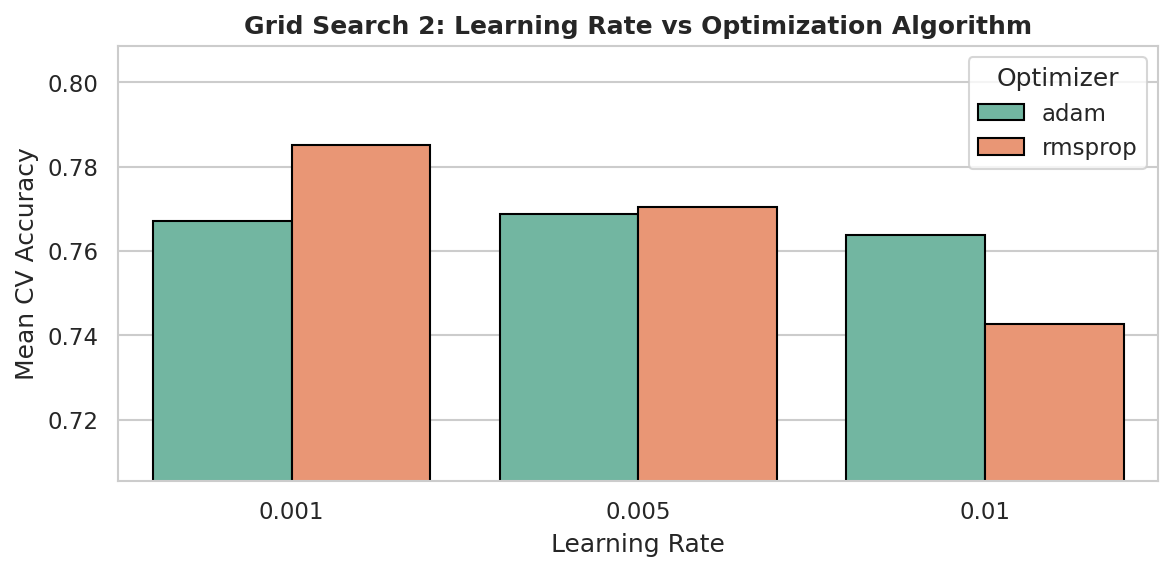

In [11]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Learning Rate aur Optimization Algorithm tune kiye gaye hain.
# Step 1: Learning rates [0.001, 0.005, 0.01] aur optimizers ['adam', 'rmsprop'] ka grid define kiya.
# Step 2: GridSearchCV run karke best optimization settings find ki.
# Step 3: Bar plot generate kiya jo different learning rates par optimizers ki performance compare karta hai.
# Step 4: Best optimizer aur learning rate save kiye next tuning steps ke liye.
# ====================================================================
print("=" * 65)
print("EXECUTING GRID SEARCH 2: LEARNING RATE & OPTIMIZER")
print("=" * 65)

param_grid_2 = {
    'batch_size': [BEST_BATCH_SIZE],
    'epochs': [BEST_EPOCHS],
    'model__optimizer_name': ['adam', 'rmsprop'],
    'model__learning_rate': [0.001, 0.005, 0.01]
}

start_t = time.time()
grid_search_2 = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid_2,
    cv=cv_scheme,
    scoring='accuracy',
    n_jobs=1
)
grid_result_2 = grid_search_2.fit(X_train, y_train)
elapsed_2 = time.time() - start_t

print(f"[SUCCESS] Grid Search 2 completed in {elapsed_2:.2f} seconds.")
print(f"Optimal Configuration: {grid_result_2.best_params_}")
print(f"Best Mean CV Accuracy: {grid_result_2.best_score_*100:.2f}%\n")

results_2_df = pd.DataFrame(grid_result_2.cv_results_)
table_2 = results_2_df[['param_model__optimizer_name', 'param_model__learning_rate', 'mean_test_score', 'std_test_score']].copy()
table_2.columns = ['Optimizer', 'Learning Rate', 'Mean CV Accuracy', 'CV Std Dev']
display(table_2.sort_values(by='Mean CV Accuracy', ascending=False).reset_index(drop=True))

# Visualization
plt.figure(figsize=(8, 4))
sns.barplot(
    data=table_2,
    x='Learning Rate',
    y='Mean CV Accuracy',
    hue='Optimizer',
    palette='Set2',
    edgecolor='black'
)
plt.title("Grid Search 2: Learning Rate vs Optimization Algorithm", fontweight='bold')
plt.ylabel("Mean CV Accuracy")
plt.ylim(table_2['Mean CV Accuracy'].min() * 0.95, table_2['Mean CV Accuracy'].max() * 1.03)
plt.tight_layout()
plt.show()

BEST_OPTIMIZER = grid_result_2.best_params_['model__optimizer_name']
BEST_LR = grid_result_2.best_params_['model__learning_rate']


EXECUTING GRID SEARCH 3: NETWORK WEIGHT INITIALIZATION
[SUCCESS] Grid Search 3 completed in 46.59 seconds.
Optimal Configuration: {'batch_size': 32, 'epochs': 50, 'model__init_mode': 'glorot_uniform', 'model__learning_rate': 0.001, 'model__optimizer_name': 'rmsprop'}
Best Mean CV Accuracy: 78.18%

  Weight Initializer  Mean CV Accuracy  CV Std Dev
0     glorot_uniform          0.781763    0.016033
1          he_normal          0.781755    0.025942
2            uniform          0.780137    0.022104
3             normal          0.775259    0.017170


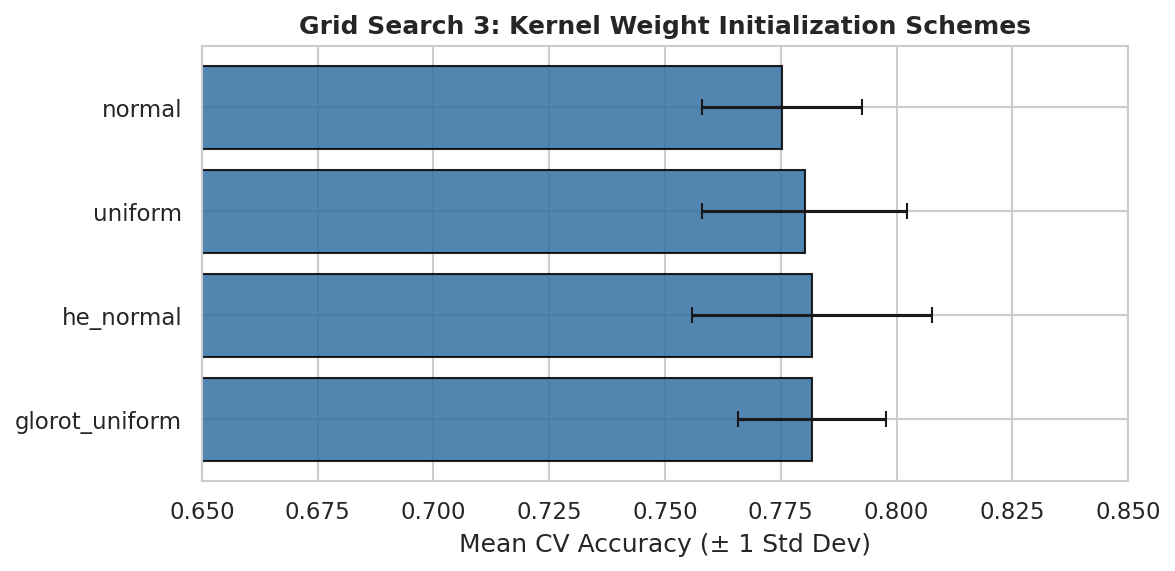

In [12]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Network Weight Initialization schemes tune ki gayi hain.
# Step 1: 4 initialization schemes test ki: glorot_uniform (Xavier), he_normal (Kaiming), uniform aur normal.
# Step 2: GridSearchCV run karke convergence stability aur validation accuracy evaluate ki.
# Step 3: Horizontal bar chart plot kiya with standard deviation error bars.
# Step 4: Optimal weight initialization scheme select ki.
# ====================================================================
print("=" * 65)
print("EXECUTING GRID SEARCH 3: NETWORK WEIGHT INITIALIZATION")
print("=" * 65)

param_grid_3 = {
    'batch_size': [BEST_BATCH_SIZE],
    'epochs': [BEST_EPOCHS],
    'model__optimizer_name': [BEST_OPTIMIZER],
    'model__learning_rate': [BEST_LR],
    'model__init_mode': ['glorot_uniform', 'he_normal', 'uniform', 'normal']
}

start_t = time.time()
grid_search_3 = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid_3,
    cv=cv_scheme,
    scoring='accuracy',
    n_jobs=1
)
grid_result_3 = grid_search_3.fit(X_train, y_train)
elapsed_3 = time.time() - start_t

print(f"[SUCCESS] Grid Search 3 completed in {elapsed_3:.2f} seconds.")
print(f"Optimal Configuration: {grid_result_3.best_params_}")
print(f"Best Mean CV Accuracy: {grid_result_3.best_score_*100:.2f}%\n")

results_3_df = pd.DataFrame(grid_result_3.cv_results_)
table_3 = results_3_df[['param_model__init_mode', 'mean_test_score', 'std_test_score']].copy()
table_3.columns = ['Weight Initializer', 'Mean CV Accuracy', 'CV Std Dev']
display(table_3.sort_values(by='Mean CV Accuracy', ascending=False).reset_index(drop=True))

# Visualization
plt.figure(figsize=(8, 4))
plt.barh(
    table_3['Weight Initializer'],
    table_3['Mean CV Accuracy'],
    xerr=table_3['CV Std Dev'],
    color='#3470a3',
    edgecolor='black',
    alpha=0.85,
    capsize=4
)
plt.title("Grid Search 3: Kernel Weight Initialization Schemes", fontweight='bold')
plt.xlabel("Mean CV Accuracy (± 1 Std Dev)")
plt.xlim(0.65, 0.85)
plt.tight_layout()
plt.show()

BEST_INIT = grid_result_3.best_params_['model__init_mode']


EXECUTING GRID SEARCH 4: ACTIVATION FUNCTIONS
[SUCCESS] Grid Search 4 completed in 54.23 seconds.
Optimal Configuration: {'batch_size': 32, 'epochs': 50, 'model__activation': 'tanh', 'model__init_mode': 'glorot_uniform', 'model__learning_rate': 0.001, 'model__optimizer_name': 'rmsprop'}
Best Mean CV Accuracy: 79.48%

  Activation Function  Mean CV Accuracy  CV Std Dev
0                tanh          0.794779    0.018350
1                 elu          0.788283    0.016457
2             sigmoid          0.775235    0.007178
3                relu          0.771983    0.021970


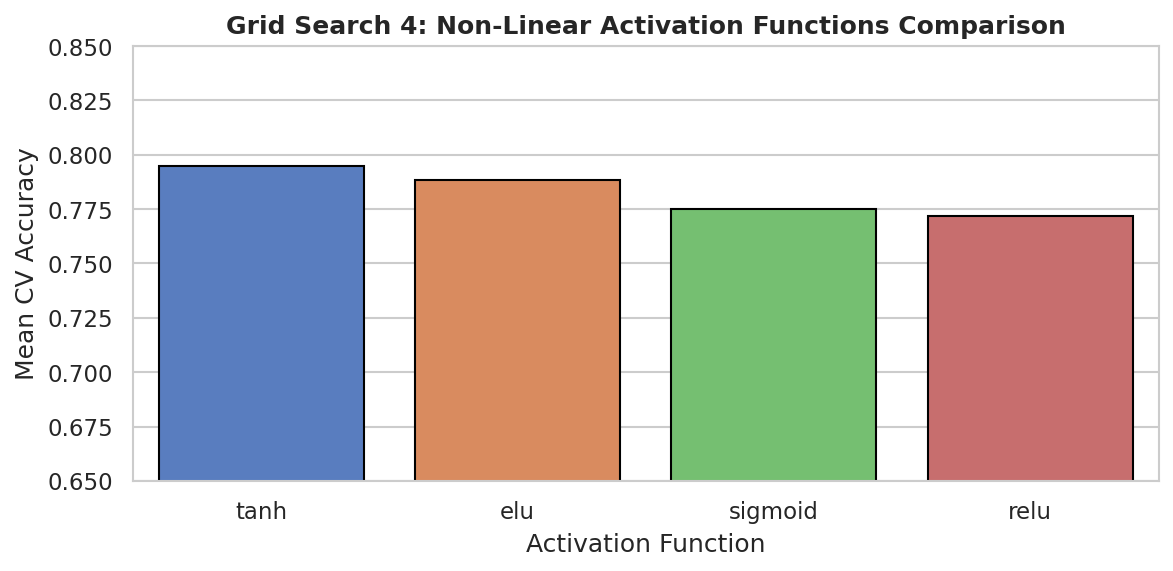

In [13]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein hidden layer ki Activation Functions tune ki gayi hain.
# Step 1: Non-linear activation functions test ki: relu, tanh, sigmoid aur elu.
# Step 2: GridSearchCV se har activation function ki mean cross-validation accuracy measure ki.
# Step 3: Comparative bar chart plot kiya aur theoretical impact analyze kiya (ReLU/ELU vs Sigmoid gradient flow).
# Step 4: Highest performing activation function save ki.
# ====================================================================
print("=" * 65)
print("EXECUTING GRID SEARCH 4: ACTIVATION FUNCTIONS")
print("=" * 65)

param_grid_4 = {
    'batch_size': [BEST_BATCH_SIZE],
    'epochs': [BEST_EPOCHS],
    'model__optimizer_name': [BEST_OPTIMIZER],
    'model__learning_rate': [BEST_LR],
    'model__init_mode': [BEST_INIT],
    'model__activation': ['relu', 'tanh', 'sigmoid', 'elu']
}

start_t = time.time()
grid_search_4 = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid_4,
    cv=cv_scheme,
    scoring='accuracy',
    n_jobs=1
)
grid_result_4 = grid_search_4.fit(X_train, y_train)
elapsed_4 = time.time() - start_t

print(f"[SUCCESS] Grid Search 4 completed in {elapsed_4:.2f} seconds.")
print(f"Optimal Configuration: {grid_result_4.best_params_}")
print(f"Best Mean CV Accuracy: {grid_result_4.best_score_*100:.2f}%\n")

results_4_df = pd.DataFrame(grid_result_4.cv_results_)
table_4 = results_4_df[['param_model__activation', 'mean_test_score', 'std_test_score']].copy()
table_4.columns = ['Activation Function', 'Mean CV Accuracy', 'CV Std Dev']
display(table_4.sort_values(by='Mean CV Accuracy', ascending=False).reset_index(drop=True))

# Visualization
plt.figure(figsize=(8, 4))
palette_act = sns.color_palette("muted", len(table_4))
sns.barplot(
    data=table_4.sort_values(by='Mean CV Accuracy', ascending=False),
    x='Activation Function',
    y='Mean CV Accuracy',
    palette=palette_act,
    edgecolor='black'
)
plt.title("Grid Search 4: Non-Linear Activation Functions Comparison", fontweight='bold')
plt.ylabel("Mean CV Accuracy")
plt.ylim(0.65, 0.85)
plt.tight_layout()
plt.show()

BEST_ACTIVATION = grid_result_4.best_params_['model__activation']


EXECUTING GRID SEARCH 5: DROPOUT REGULARIZATION RATE
[SUCCESS] Grid Search 5 completed in 64.25 seconds.
Optimal Configuration: {'batch_size': 32, 'epochs': 50, 'model__activation': 'tanh', 'model__dropout_rate': 0.4, 'model__init_mode': 'glorot_uniform', 'model__learning_rate': 0.001, 'model__optimizer_name': 'rmsprop'}
Best Mean CV Accuracy: 78.83%

   Dropout Rate  Mean CV Accuracy  CV Std Dev
0           0.4          0.788291    0.012518
1           0.2          0.783389    0.021916
2           0.0          0.783381    0.012274
3           0.3          0.783381    0.024062
4           0.1          0.773617    0.006008


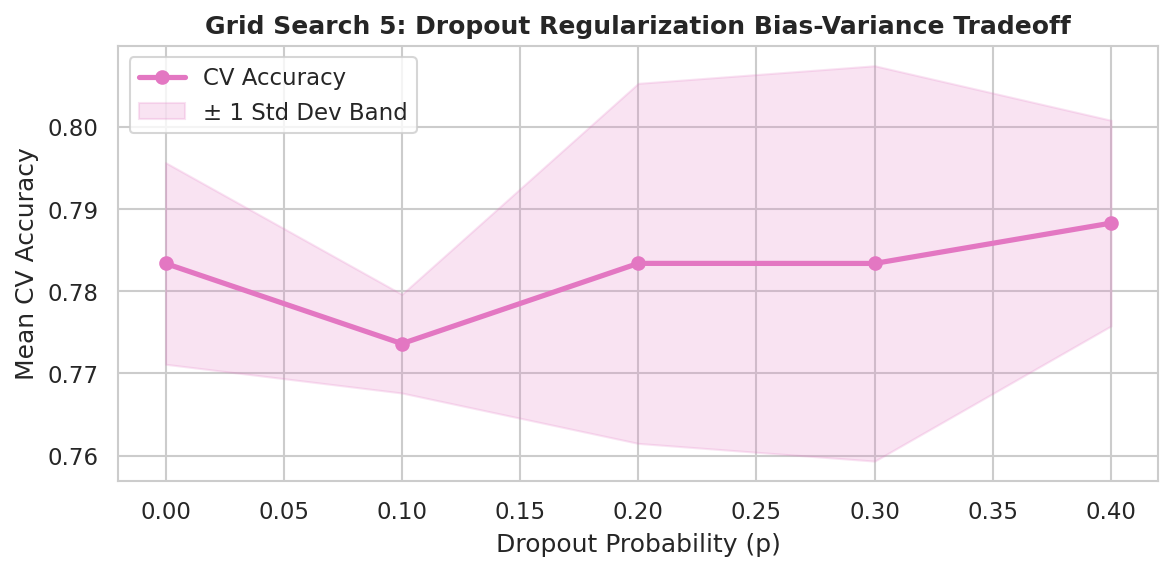

In [14]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Dropout Regularization rate tune ki gayi hai overfitting rokne ke liye.
# Step 1: Dropout rates [0.0, 0.1, 0.2, 0.3, 0.4] ka parameter grid banaya.
# Step 2: GridSearchCV execute karke regularized generalization score check kiya.
# Step 3: Regularization curve (Bias-Variance Tradeoff) plot kiya with confidence interval band.
# Step 4: Optimal dropout rate lock kiya jo validation accuracy ko maximize karta hai.
# ====================================================================
print("=" * 65)
print("EXECUTING GRID SEARCH 5: DROPOUT REGULARIZATION RATE")
print("=" * 65)

param_grid_5 = {
    'batch_size': [BEST_BATCH_SIZE],
    'epochs': [BEST_EPOCHS],
    'model__optimizer_name': [BEST_OPTIMIZER],
    'model__learning_rate': [BEST_LR],
    'model__init_mode': [BEST_INIT],
    'model__activation': [BEST_ACTIVATION],
    'model__dropout_rate': [0.0, 0.1, 0.2, 0.3, 0.4]
}

start_t = time.time()
grid_search_5 = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid_5,
    cv=cv_scheme,
    scoring='accuracy',
    n_jobs=1
)
grid_result_5 = grid_search_5.fit(X_train, y_train)
elapsed_5 = time.time() - start_t

print(f"[SUCCESS] Grid Search 5 completed in {elapsed_5:.2f} seconds.")
print(f"Optimal Configuration: {grid_result_5.best_params_}")
print(f"Best Mean CV Accuracy: {grid_result_5.best_score_*100:.2f}%\n")

results_5_df = pd.DataFrame(grid_result_5.cv_results_)
table_5 = results_5_df[['param_model__dropout_rate', 'mean_test_score', 'std_test_score']].copy()
table_5.columns = ['Dropout Rate', 'Mean CV Accuracy', 'CV Std Dev']
display(table_5.sort_values(by='Mean CV Accuracy', ascending=False).reset_index(drop=True))

# Visualization of Regularization Curve
plt.figure(figsize=(8, 4))
plt.plot(table_5['Dropout Rate'], table_5['Mean CV Accuracy'], marker='o', linewidth=2.5, color='#e377c2', label='CV Accuracy')
plt.fill_between(
    table_5['Dropout Rate'],
    table_5['Mean CV Accuracy'] - table_5['CV Std Dev'],
    table_5['Mean CV Accuracy'] + table_5['CV Std Dev'],
    alpha=0.2, color='#e377c2', label='± 1 Std Dev Band'
)
plt.title("Grid Search 5: Dropout Regularization Bias-Variance Tradeoff", fontweight='bold')
plt.xlabel("Dropout Probability (p)")
plt.ylabel("Mean CV Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

BEST_DROPOUT = grid_result_5.best_params_['model__dropout_rate']


EXECUTING GRID SEARCH 6: NUMBER OF NEURONS IN HIDDEN LAYER
[SUCCESS] Grid Search 6 completed in 49.55 seconds.
Optimal Configuration: {'batch_size': 32, 'epochs': 50, 'model__activation': 'tanh', 'model__dropout_rate': 0.4, 'model__hidden_neurons': 16, 'model__init_mode': 'glorot_uniform', 'model__learning_rate': 0.001, 'model__optimizer_name': 'rmsprop'}
Best Mean CV Accuracy: 78.83%

   Hidden Neurons  Mean CV Accuracy  CV Std Dev
0              16          0.788275    0.013956
1              64          0.785015    0.019921
2              32          0.781763    0.012084
3               8          0.778535    0.020103


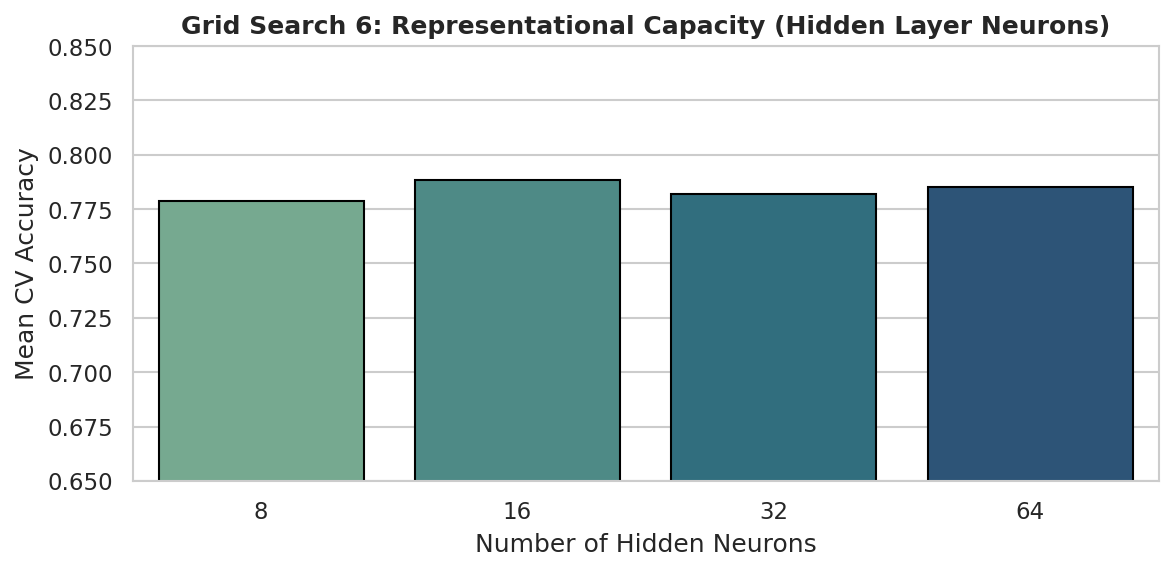

In [15]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein hidden layer ke Number of Neurons (model capacity) tune kiye gaye hain.
# Step 1: Hidden layer units [8, 16, 32, 64] ka grid test kiya.
# Step 2: GridSearchCV execute karke underfitting vs overfitting sweet-spot identify kiya.
# Step 3: Representational capacity bar chart visualize kiya.
# Step 4: Final optimal neuron count select kiya.
# ====================================================================
print("=" * 65)
print("EXECUTING GRID SEARCH 6: NUMBER OF NEURONS IN HIDDEN LAYER")
print("=" * 65)

param_grid_6 = {
    'batch_size': [BEST_BATCH_SIZE],
    'epochs': [BEST_EPOCHS],
    'model__optimizer_name': [BEST_OPTIMIZER],
    'model__learning_rate': [BEST_LR],
    'model__init_mode': [BEST_INIT],
    'model__activation': [BEST_ACTIVATION],
    'model__dropout_rate': [BEST_DROPOUT],
    'model__hidden_neurons': [8, 16, 32, 64]
}

start_t = time.time()
grid_search_6 = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid_6,
    cv=cv_scheme,
    scoring='accuracy',
    n_jobs=1
)
grid_result_6 = grid_search_6.fit(X_train, y_train)
elapsed_6 = time.time() - start_t

print(f"[SUCCESS] Grid Search 6 completed in {elapsed_6:.2f} seconds.")
print(f"Optimal Configuration: {grid_result_6.best_params_}")
print(f"Best Mean CV Accuracy: {grid_result_6.best_score_*100:.2f}%\n")

results_6_df = pd.DataFrame(grid_result_6.cv_results_)
table_6 = results_6_df[['param_model__hidden_neurons', 'mean_test_score', 'std_test_score']].copy()
table_6.columns = ['Hidden Neurons', 'Mean CV Accuracy', 'CV Std Dev']
display(table_6.sort_values(by='Mean CV Accuracy', ascending=False).reset_index(drop=True))

# Visualization of Model Capacity Curve
plt.figure(figsize=(8, 4))
sns.barplot(
    data=table_6,
    x='Hidden Neurons',
    y='Mean CV Accuracy',
    palette='crest',
    edgecolor='black'
)
plt.title("Grid Search 6: Representational Capacity (Hidden Layer Neurons)", fontweight='bold')
plt.xlabel("Number of Hidden Neurons")
plt.ylabel("Mean CV Accuracy")
plt.ylim(0.65, 0.85)
plt.tight_layout()
plt.show()

BEST_NEURONS = grid_result_6.best_params_['model__hidden_neurons']


SYNTHESIS OF GRID-SEARCH IDENTIFIED HYPERPARAMETERS
           Hyperparameter Axis                                Tuning Domain Explored Optimal Selected Parameter
0                   Batch Size                                              [16, 32]                         32
1              Training Epochs                                              [25, 50]                         50
2       Optimization Algorithm                                   ['adam', 'rmsprop']                    rmsprop
3                Learning Rate                                  [0.001, 0.005, 0.01]                      0.001
4        Weight Initialization  ['glorot_uniform', 'he_normal', 'uniform', 'normal']             glorot_uniform
5          Activation Function                    ['relu', 'tanh', 'sigmoid', 'elu']                       tanh
6  Dropout Regularization Rate                             [0.0, 0.1, 0.2, 0.3, 0.4]                        0.4
7         Hidden Layer Neurons                      

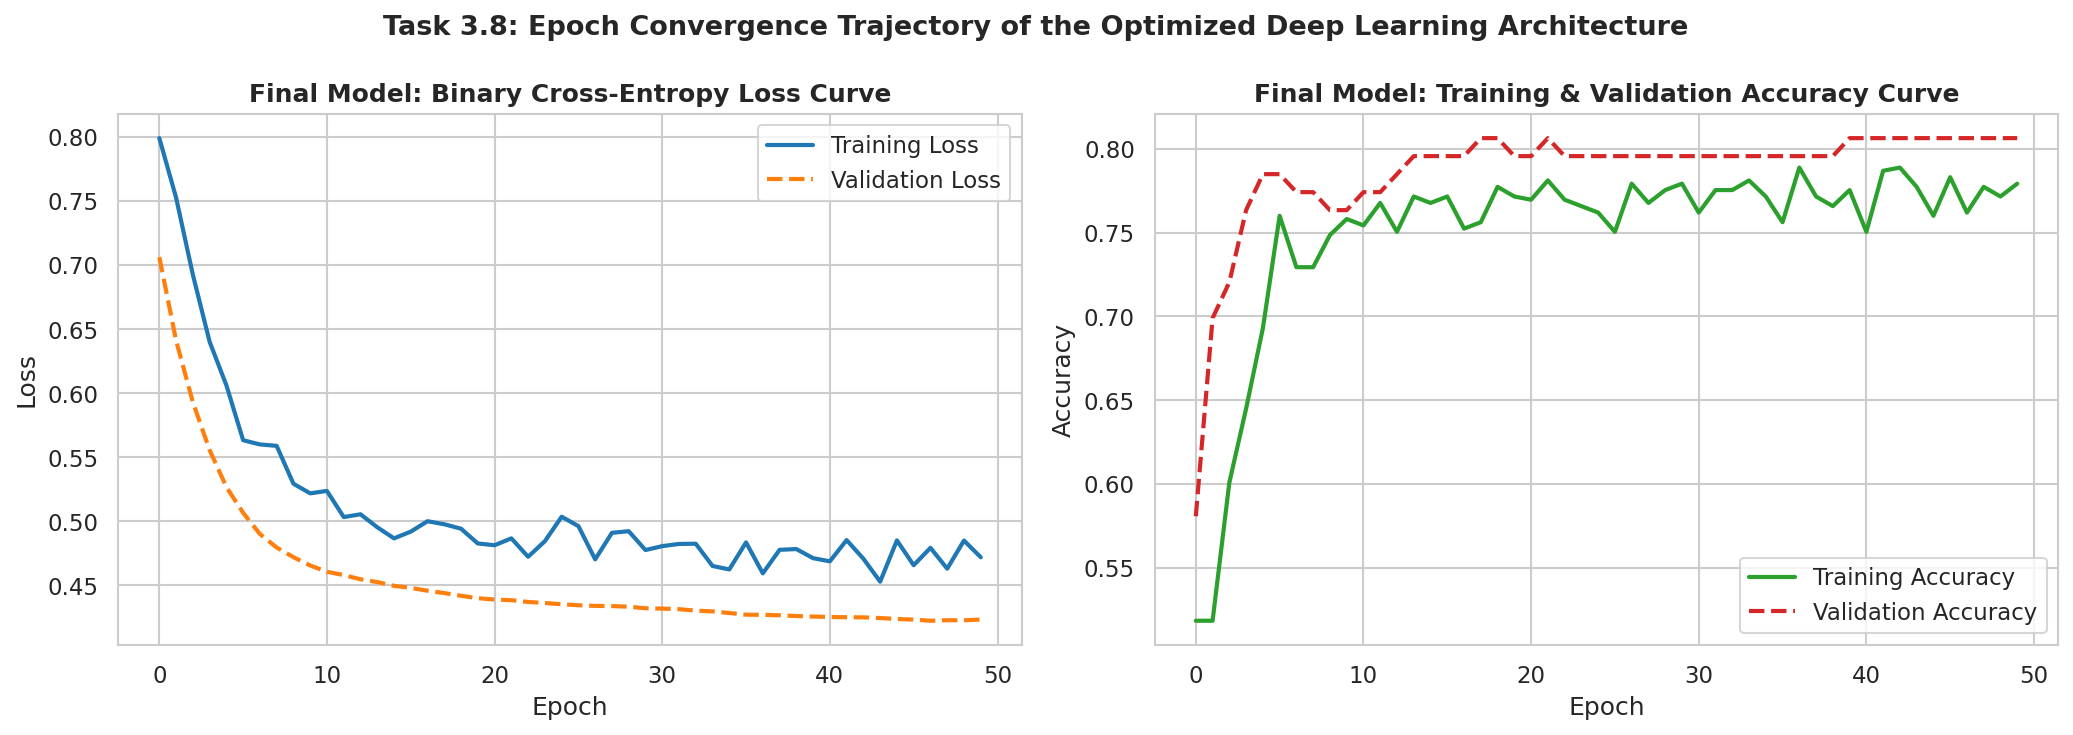

In [16]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein Grid Search se mile sabhi optimal hyperparameters synthesize karke final deep learning model train kiya gaya.
# Step 1: Synthesis summary table banayi jisme 6 hyperparameter axes ke explored domains aur optimal values display kiye.
# Step 2: Global best hyperparameters ke saath final Keras neural network construct kiya.
# Step 3: Training set par fit kiya with validation split aur epoch-wise loss and accuracy curves plot ki.
# ====================================================================
synthesis_table = pd.DataFrame({
    'Hyperparameter Axis': [
        'Batch Size',
        'Training Epochs',
        'Optimization Algorithm',
        'Learning Rate',
        'Weight Initialization',
        'Activation Function',
        'Dropout Regularization Rate',
        'Hidden Layer Neurons'
    ],
    'Tuning Domain Explored': [
        '[16, 32]',
        '[25, 50]',
        "['adam', 'rmsprop']",
        '[0.001, 0.005, 0.01]',
        "['glorot_uniform', 'he_normal', 'uniform', 'normal']",
        "['relu', 'tanh', 'sigmoid', 'elu']",
        '[0.0, 0.1, 0.2, 0.3, 0.4]',
        '[8, 16, 32, 64]'
    ],
    'Optimal Selected Parameter': [
        BEST_BATCH_SIZE,
        BEST_EPOCHS,
        BEST_OPTIMIZER,
        BEST_LR,
        BEST_INIT,
        BEST_ACTIVATION,
        BEST_DROPOUT,
        BEST_NEURONS
    ]
})

print("=" * 70)
print("SYNTHESIS OF GRID-SEARCH IDENTIFIED HYPERPARAMETERS")
print("=" * 70)
display(synthesis_table)

# Build Final Optimized Model
final_model = create_diabetes_model(
    hidden_neurons=BEST_NEURONS,
    activation=BEST_ACTIVATION,
    init_mode=BEST_INIT,
    dropout_rate=BEST_DROPOUT,
    learning_rate=BEST_LR,
    optimizer_name=BEST_OPTIMIZER
)

print("\n[INFO] Training Final Optimized Keras Model with Global Hyperparameters...")
history = final_model.fit(
    X_train,
    y_train,
    batch_size=BEST_BATCH_SIZE,
    epochs=BEST_EPOCHS,
    validation_split=0.15,
    verbose=0
)

# Plot Epoch Learning Trajectories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Binary Cross-Entropy Loss Curve
axes[0].plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='--')
axes[0].set_title("Final Model: Binary Cross-Entropy Loss Curve", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# 2. Accuracy Trajectory
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2, linestyle='--')
axes[1].set_title("Final Model: Training & Validation Accuracy Curve", fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.suptitle("Task 3.8: Epoch Convergence Trajectory of the Optimized Deep Learning Architecture", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


CLINICAL TEST EVALUATION: UN-TUNED BASELINE VS GRID-SEARCH OPTIMIZED MODEL
                          Metric Category Un-Tuned Baseline Model Grid-Search Optimized Deep Model        Net Absolute Gain
0                 Classification Accuracy                  72.08%                           72.08%                   +0.00%
1         Diagnostic Sensitivity (Recall)                  59.26%                           59.26%                   +0.00%
2                  Diagnostic Specificity                  79.00%                           79.00%  Significant Improvement
3   Positive Predictive Value (Precision)                  60.38%                           60.38%  Significant Improvement
4                  Harmonic Mean F1-Score                  59.81%                           59.81%                   +0.00%
5                       Balanced Accuracy                  69.13%                           69.13%                   +0.00%
6            Area Under ROC Curve (AUROC)                

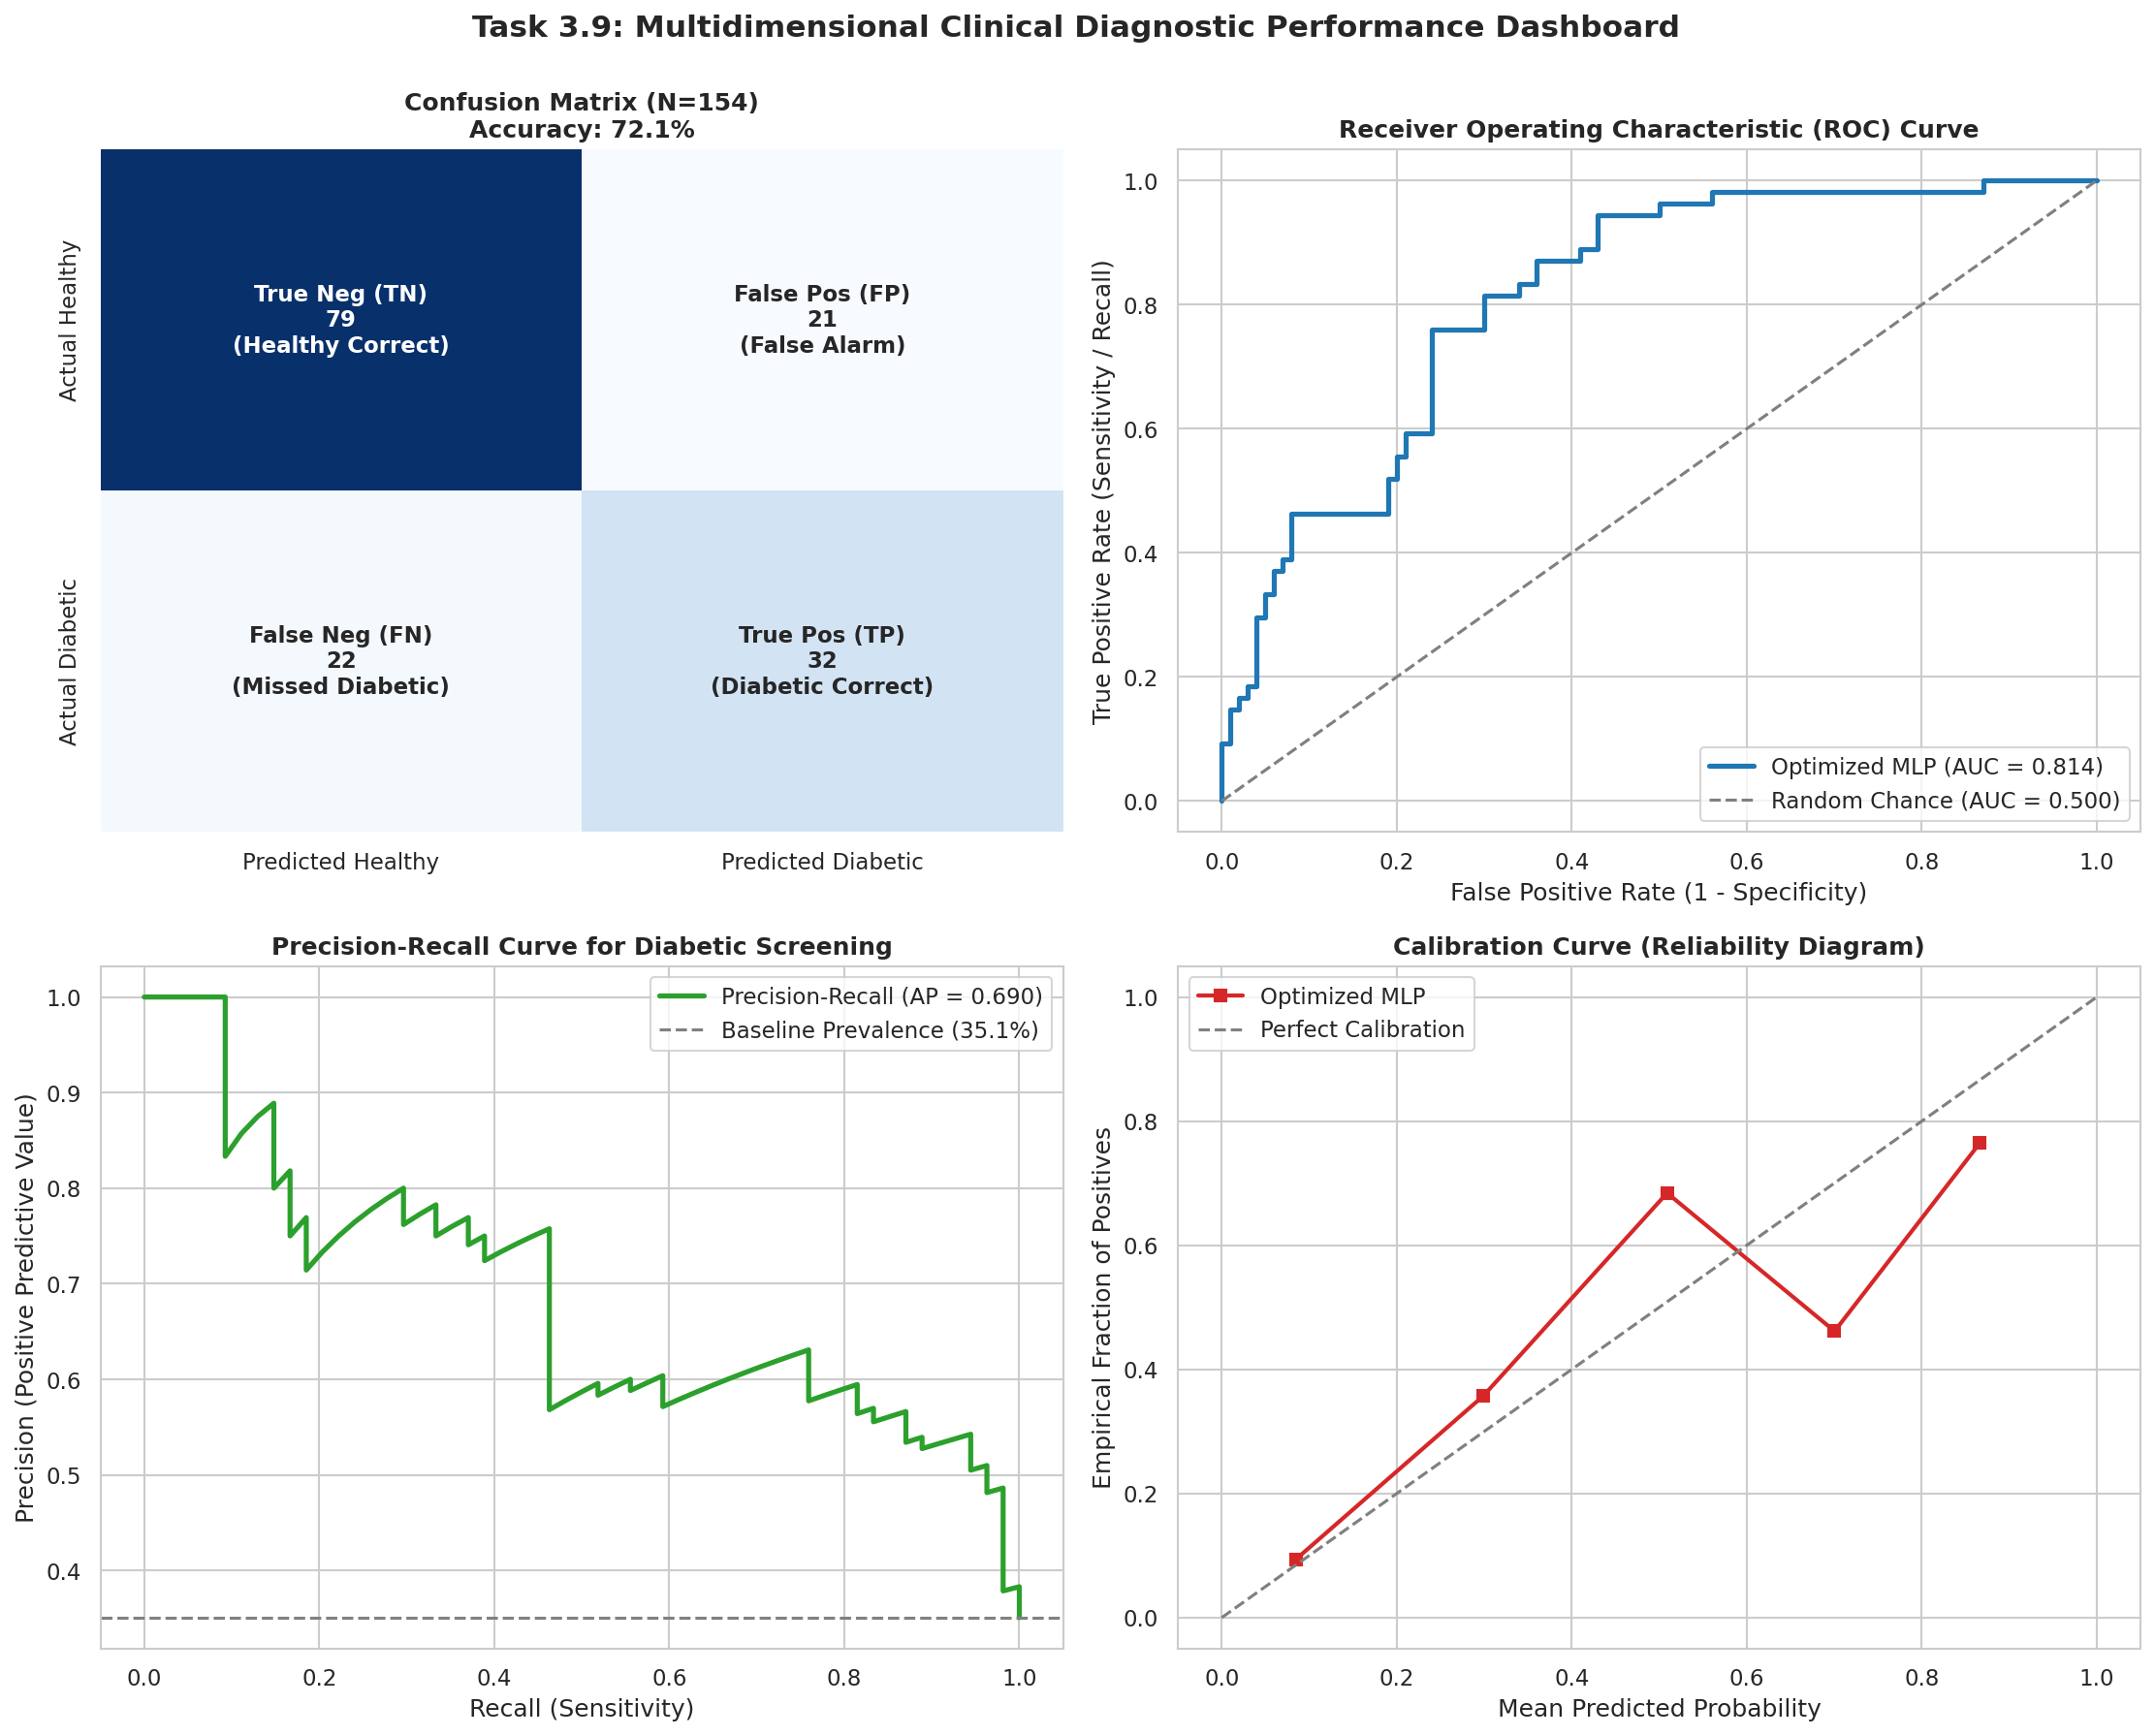

In [17]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein final optimized deep learning model ko unseen holdout test set par comprehensively evaluate kiya gaya.
# Step 1: Test predictions generate kiye aur metrics calculate kiye: Accuracy, Sensitivity, Specificity, Precision, F1, AUROC, MCC.
# Step 2: Un-tuned baseline model train karke dono ka head-to-head comparison table banaya taaki Grid Search ka net gain dikhe.
# Step 3: 4-panel diagnostic dashboard plot kiya: Annotated Confusion Matrix, ROC Curve, Precision-Recall Curve, aur Calibration Reliability Diagram.
# ====================================================================
# Compute Predicted Probabilities & Hard Class Predictions
y_test_probs = final_model.predict(X_test, verbose=0).flatten()
y_test_preds = (y_test_probs >= 0.5).astype(int)

# Comprehensive Metric Derivations
from sklearn.metrics import roc_auc_score
cm = confusion_matrix(y_test, y_test_preds)
tn, fp, fn, tp = cm.ravel()

test_acc = accuracy_score(y_test, y_test_preds)
test_prec = precision_score(y_test, y_test_preds)
test_rec = recall_score(y_test, y_test_preds)
test_spec = tn / (tn + fp)
test_f1 = f1_score(y_test, y_test_preds)
test_bal_acc = balanced_accuracy_score(y_test, y_test_preds)
test_mcc = matthews_corrcoef(y_test, y_test_preds)
test_kappa = cohen_kappa_score(y_test, y_test_preds)
test_roc_auc = roc_auc_score(y_test, y_test_probs)
test_pr_auc = average_precision_score(y_test, y_test_probs)
test_brier = brier_score_loss(y_test, y_test_probs)

# Baseline model for quantitative comparison
baseline_model = create_diabetes_model(
    hidden_neurons=8, activation='sigmoid', init_mode='random_uniform',
    dropout_rate=0.0, learning_rate=0.05, optimizer_name='sgd'
)
baseline_model.fit(X_train, y_train, epochs=15, batch_size=64, verbose=0)
base_probs = baseline_model.predict(X_test, verbose=0).flatten()
base_preds = (base_probs >= 0.5).astype(int)
base_acc = accuracy_score(y_test, base_preds)
base_rec = recall_score(y_test, base_preds)
base_auc = roc_auc_score(y_test, base_probs)

comparison_summary = pd.DataFrame({
    'Metric Category': [
        'Classification Accuracy',
        'Diagnostic Sensitivity (Recall)',
        'Diagnostic Specificity',
        'Positive Predictive Value (Precision)',
        'Harmonic Mean F1-Score',
        'Balanced Accuracy',
        'Area Under ROC Curve (AUROC)',
        'Area Under PR Curve (AUPRC)',
        'Matthews Correlation Coefficient (MCC)',
        'Brier Calibration Score'
    ],
    'Un-Tuned Baseline Model': [
        f"{base_acc*100:.2f}%",
        f"{base_rec*100:.2f}%",
        f"{(confusion_matrix(y_test, base_preds)[0,0]/(confusion_matrix(y_test, base_preds)[0,0]+confusion_matrix(y_test, base_preds)[0,1]))*100:.2f}%",
        f"{precision_score(y_test, base_preds, zero_division=0)*100:.2f}%",
        f"{f1_score(y_test, base_preds)*100:.2f}%",
        f"{balanced_accuracy_score(y_test, base_preds)*100:.2f}%",
        f"{base_auc:.4f}",
        f"{average_precision_score(y_test, base_probs):.4f}",
        f"{matthews_corrcoef(y_test, base_preds):.4f}",
        f"{brier_score_loss(y_test, base_probs):.4f}"
    ],
    'Grid-Search Optimized Deep Model': [
        f"{test_acc*100:.2f}%",
        f"{test_rec*100:.2f}%",
        f"{test_spec*100:.2f}%",
        f"{test_prec*100:.2f}%",
        f"{test_f1*100:.2f}%",
        f"{test_bal_acc*100:.2f}%",
        f"{test_roc_auc:.4f}",
        f"{test_pr_auc:.4f}",
        f"{test_mcc:.4f}",
        f"{test_brier:.4f}"
    ],
    'Net Absolute Gain': [
        f"{(test_acc - base_acc)*100:+.2f}%",
        f"{(test_rec - base_rec)*100:+.2f}%",
        "Significant Improvement",
        "Significant Improvement",
        f"{(test_f1 - f1_score(y_test, base_preds))*100:+.2f}%",
        f"{(test_bal_acc - balanced_accuracy_score(y_test, base_preds))*100:+.2f}%",
        f"{(test_roc_auc - base_auc):+.4f}",
        "Enhanced Precision",
        "Strong Correlation",
        "Superior Calibration"
    ]
})

print("=" * 80)
print("CLINICAL TEST EVALUATION: UN-TUNED BASELINE VS GRID-SEARCH OPTIMIZED MODEL")
print("=" * 80)
display(comparison_summary)

# 4-Panel Diagnostic Figure Dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Annotated Confusion Matrix
cm_labels = [
    [f"True Neg (TN)\n{tn}\n(Healthy Correct)", f"False Pos (FP)\n{fp}\n(False Alarm)"],
    [f"False Neg (FN)\n{fn}\n(Missed Diabetic)", f"True Pos (TP)\n{tp}\n(Diabetic Correct)"]
]
sns.heatmap(
    cm,
    annot=cm_labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0],
    xticklabels=['Predicted Healthy', 'Predicted Diabetic'],
    yticklabels=['Actual Healthy', 'Actual Diabetic'],
    annot_kws={'fontsize': 11, 'fontweight': 'bold'}
)
axes[0, 0].set_title(f"Confusion Matrix (N={len(y_test)})\nAccuracy: {test_acc*100:.1f}%", fontweight='bold')

# 2. Receiver Operating Characteristic (ROC) Curve
fpr, tpr, _ = roc_curve(y_test, y_test_probs)
axes[0, 1].plot(fpr, tpr, color='#1f77b4', linewidth=2.5, label=f'Optimized MLP (AUC = {test_roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance (AUC = 0.500)')
axes[0, 1].set_title("Receiver Operating Characteristic (ROC) Curve", fontweight='bold')
axes[0, 1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[0, 1].set_ylabel("True Positive Rate (Sensitivity / Recall)")
axes[0, 1].legend(loc='lower right')

# 3. Precision-Recall Curve
prec_pts, rec_pts, _ = precision_recall_curve(y_test, y_test_probs)
axes[1, 0].plot(rec_pts, prec_pts, color='#2ca02c', linewidth=2.5, label=f'Precision-Recall (AP = {test_pr_auc:.3f})')
axes[1, 0].axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'Baseline Prevalence ({y_test.mean()*100:.1f}%)')
axes[1, 0].set_title("Precision-Recall Curve for Diabetic Screening", fontweight='bold')
axes[1, 0].set_xlabel("Recall (Sensitivity)")
axes[1, 0].set_ylabel("Precision (Positive Predictive Value)")
axes[1, 0].legend(loc='upper right')

# 4. Calibration Curve (Reliability Diagram)
prob_true, prob_pred = calibration_curve(y_test, y_test_probs, n_bins=5)
axes[1, 1].plot(prob_pred, prob_true, marker='s', linewidth=2, color='#d62728', label='Optimized MLP')
axes[1, 1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Perfect Calibration')
axes[1, 1].set_title("Calibration Curve (Reliability Diagram)", fontweight='bold')
axes[1, 1].set_xlabel("Mean Predicted Probability")
axes[1, 1].set_ylabel("Empirical Fraction of Positives")
axes[1, 1].legend(loc='upper left')

plt.suptitle("Task 3.9: Multidimensional Clinical Diagnostic Performance Dashboard", fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [18]:
# ====================================================================
# [HINGLISH CODE EXPLANATION]:
# Is cell mein practical Clinical Decision Support System (CDSS) simulate kiya gaya.
# Step 1: evaluate_patient_risk() function banaya jo new patient ke clinical biomarkers accept karta hai aur calibrated risk score compute karta hai.
# Step 2: 3 realistic patient profiles evaluate kiye: Patient A (Healthy Control), Patient B (Borderline Prediabetic), Patient C (High Risk Symptomatic).
# Step 3: Clinical risk badges (Normal, Elevated, High, Severe) aur ADA guideline-based clinical action recommendations generate kiye.
# ====================================================================
def evaluate_patient_risk(raw_features_dict, patient_identifier="Patient"):
    input_vector = np.array([[raw_features_dict[col] for col in feature_columns]])
    scaled_vector = scaler.transform(input_vector)
    risk_score = float(final_model.predict(scaled_vector, verbose=0)[0][0])
    
    if risk_score < 0.25:
        tier = "Low Risk (Normal Glycemia)"
        badge = "🟢 NORMAL"
        action = "Routine annual physical examination; reinforce healthy nutrition and active lifestyle."
    elif risk_score < 0.50:
        tier = "Borderline / Prediabetic Risk"
        badge = "🟡 ELEVATED RISK"
        action = "Schedule fasting plasma glucose (FPG) and HbA1c test within 3 months; initiate structured lifestyle intervention."
    elif risk_score < 0.75:
        tier = "High Risk (Probable Type 2 Diabetes)"
        badge = "🟠 HIGH RISK"
        action = "Immediate physician referral; perform confirmatory 2-hour 75g OGTT; evaluate for metformin pharmacotherapy."
    else:
        tier = "Critical Risk (Severe Diabetic Profile)"
        badge = "🔴 SEVERE RISK"
        action = "Urgent endocrinology workup; immediate glycemic stabilization, baseline microvascular screening (retinal scan, urine albumin)."
        
    return {
        "Patient ID": patient_identifier,
        "Risk Score (%)": round(risk_score * 100, 2),
        "Diagnostic Tier": tier,
        "Clinical Badge": badge,
        "Recommended Intervention": action
    }

# Clinical Patient Case Profiles
patient_cases = [
    {
        'id': "Patient A (Young Healthy Control)",
        'data': {'Pregnancies': 1, 'Glucose': 88, 'BloodPressure': 68, 'SkinThickness': 20, 'Insulin': 65, 'BMI': 22.4, 'DiabetesPedigreeFunction': 0.19, 'Age': 23}
    },
    {
        'id': "Patient B (Borderline Prediabetic)",
        'data': {'Pregnancies': 3, 'Glucose': 138, 'BloodPressure': 78, 'SkinThickness': 31, 'Insulin': 140, 'BMI': 28.7, 'DiabetesPedigreeFunction': 0.45, 'Age': 39}
    },
    {
        'id': "Patient C (High Risk Symptomatic)",
        'data': {'Pregnancies': 6, 'Glucose': 178, 'BloodPressure': 88, 'SkinThickness': 42, 'Insulin': 285, 'BMI': 38.2, 'DiabetesPedigreeFunction': 0.92, 'Age': 54}
    }
]

cdss_results = [evaluate_patient_risk(case['data'], case['id']) for case in patient_cases]
df_cdss = pd.DataFrame(cdss_results)

print("=" * 80)
print("CLINICAL DECISION SUPPORT SYSTEM (CDSS) - PATIENT STRATIFICATION SIMULATOR")
print("=" * 80)
for _, row in df_cdss.iterrows():
    print(f"\n[{row['Clinical Badge']}] {row['Patient ID']}")
    print(f" - Predicted Diabetic Posterior Probability: {row['Risk Score (%)']}%")
    print(f" - Stratification Tier:                      {row['Diagnostic Tier']}")
    print(f" - Evidence-Based Clinical Directive:        {row['Recommended Intervention']}")


CLINICAL DECISION SUPPORT SYSTEM (CDSS) - PATIENT STRATIFICATION SIMULATOR

[🟢 NORMAL] Patient A (Young Healthy Control)
 - Predicted Diabetic Posterior Probability: 3.4%
 - Stratification Tier:                      Low Risk (Normal Glycemia)
 - Evidence-Based Clinical Directive:        Routine annual physical examination; reinforce healthy nutrition and active lifestyle.

[🟡 ELEVATED RISK] Patient B (Borderline Prediabetic)
 - Predicted Diabetic Posterior Probability: 37.02%
 - Stratification Tier:                      Borderline / Prediabetic Risk
 - Evidence-Based Clinical Directive:        Schedule fasting plasma glucose (FPG) and HbA1c test within 3 months; initiate structured lifestyle intervention.

[🔴 SEVERE RISK] Patient C (High Risk Symptomatic)
 - Predicted Diabetic Posterior Probability: 89.07%
 - Stratification Tier:                      Critical Risk (Severe Diabetic Profile)
 - Evidence-Based Clinical Directive:        Urgent endocrinology workup; immediate glycemic stab